# Import Necessary Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
df = pd.read_csv(url,header= None)

# Check Dataset Shape

In [ ]:
df.shape

(768, 9)

# View First Rows

In [ ]:
df.head()

,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# View Last Rows

In [ ]:
df.tail()

,0,1,2,3,4,5,6,7,8
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


# Check Column Names

In [ ]:
df.columns

Index([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype='int64')

# Check Data Types

In [ ]:
df.dtypes

,0
0,int64
1,int64
2,int64
3,int64
4,int64
5,float64
6,float64
7,int64
8,int64


# Check Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       768 non-null    int64  
 1   1       768 non-null    int64  
 2   2       768 non-null    int64  
 3   3       768 non-null    int64  
 4   4       768 non-null    int64  
 5   5       768 non-null    float64
 6   6       768 non-null    float64
 7   7       768 non-null    int64  
 8   8       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# Check Missing Values

In [ ]:
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0


# Check Duplicate Rows

In [ ]:
df.duplicated().sum()

np.int64(0)

# Check Unique Values

In [ ]:
df.nunique()

,0
0,17
1,136
2,47
3,51
4,186
5,248
6,517
7,52
8,2


In [ ]:
df.head(10)

,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


# Check Target Distribution

In [ ]:
df[8].value_counts()

,count
8,
0,500
1,268


### Check Numerical vs Categorical Features

In [ ]:
df.dtypes

,0
0,int64
1,int64
2,int64
3,int64
4,int64
5,float64
6,float64
7,int64
8,int64


# Calculate the minimum and maximum

In [ ]:
df.agg(['min', 'max'])

,0,1,2,3,4,5,6,7,8
min,0,0,0,0,0,0.0,0.078,21,0
max,17,199,122,99,846,67.1,2.420,81,1


# Investigate Zero Values  -->

In [ ]:
(df == 0).sum()

,0
0,111
1,5
2,35
3,227
4,374
5,11
6,0
7,0
8,500


# Check Descriptive Statistics

In [ ]:
df.describe()

,0,1,2,3,4,5,6,7,8
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Investigate Zero Values

In [ ]:
zero_counts = (df == 0).sum()
zero_percent = (zero_counts / len(df)) * 100

pd.DataFrame({
    'Zero Count': zero_counts,
    'Zero Percentage': zero_percent
})

,Zero Count,Zero Percentage
0,111,14.453125
1,5,0.651042
2,35,4.557292
3,227,29.557292
4,374,48.697917
5,11,1.432292
6,0,0.000000
7,0,0.000000
8,500,65.104167


# actual rows containing suspicious zeros

In [ ]:
df[(df[[1, 2, 3, 4, 5]] == 0).any(axis=1)].head(20)

,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
5,5,116,74,0,0,25.6,0.201,30,0
7,10,115,0,0,0,35.3,0.134,29,0
9,8,125,96,0,0,0.0,0.232,54,1
10,4,110,92,0,0,37.6,0.191,30,0
11,10,168,74,0,0,38.0,0.537,34,1
12,10,139,80,0,0,27.1,1.441,57,0
15,7,100,0,0,0,30.0,0.484,32,1


# Handle Missing/Invalid Values

In [ ]:
df[[1, 2, 3, 4, 5]].replace(0, np.nan).median()

,0
1,117.0
2,72.0
3,29.0
4,125.0
5,32.3


# Simulate Missing Values Before Cleaning

In [ ]:
df[[1, 2, 3, 4, 5]].replace(0, np.nan).isnull().sum()

,0
1,5
2,35
3,227
4,374
5,11


# Handle Missing/Invalid Values


In [ ]:
df[[1, 2, 3, 4, 5]] = df[[1, 2, 3, 4, 5]].replace(0, np.nan)

df[[1, 2, 3, 4, 5]] = df[[1, 2, 3, 4, 5]].fillna(
    df[[1, 2, 3, 4, 5]].median()
)

In [ ]:
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0


# Verify Cleaning

In [ ]:
(df[[0, 8]] == 0).sum()

,0
0,111
8,500


#  data analysis

In [ ]:
# Detect Outliers

id="e8x4rm"
Q1 = df.iloc[:, :8].quantile(0.25)
Q3 = df.iloc[:, :8].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

pd.DataFrame({
    'Q1': Q1,
    'Q3': Q3,
    'IQR': IQR,
    'Lower Bound': lower_bound,
    'Upper Bound': upper_bound
})

,Q1,Q3,IQR,Lower Bound,Upper Bound
0,1.00000,6.00000,5.0000,-6.500,13.500
1,99.75000,140.25000,40.5000,39.000,201.000
2,64.00000,80.00000,16.0000,40.000,104.000
3,25.00000,32.00000,7.0000,14.500,42.500
4,121.50000,127.25000,5.7500,112.875,135.875
5,27.50000,36.60000,9.1000,13.850,50.250
6,0.24375,0.62625,0.3825,-0.330,1.200
7,24.00000,41.00000,17.0000,-1.500,66.500


In [ ]:
# count the outliers

outlier_counts = ((df.iloc[:, :8] < lower_bound) | (df.iloc[:, :8] > upper_bound)).sum()

outlier_counts

,0
0,4
1,0
2,14
3,87
4,346
5,8
6,29
7,9


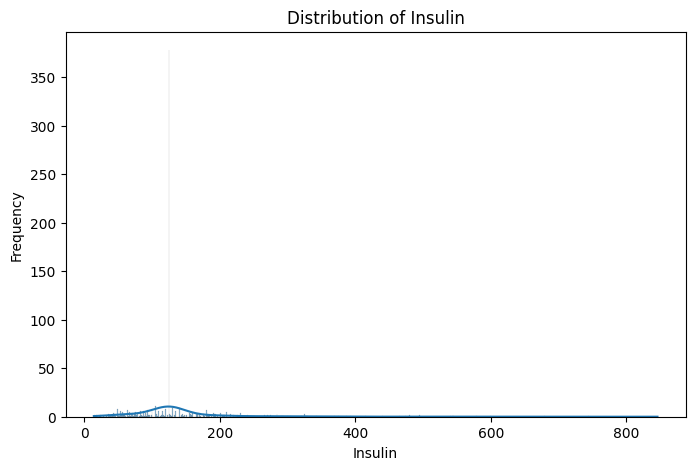

In [ ]:
# Analyze Feature Distributions
plt.figure(figsize=(8, 5))
sns.histplot(df[4], kde=True)
plt.xlabel("Insulin")
plt.ylabel("Frequency")
plt.title("Distribution of Insulin")
plt.show()

# Analyze Glucose Distribution

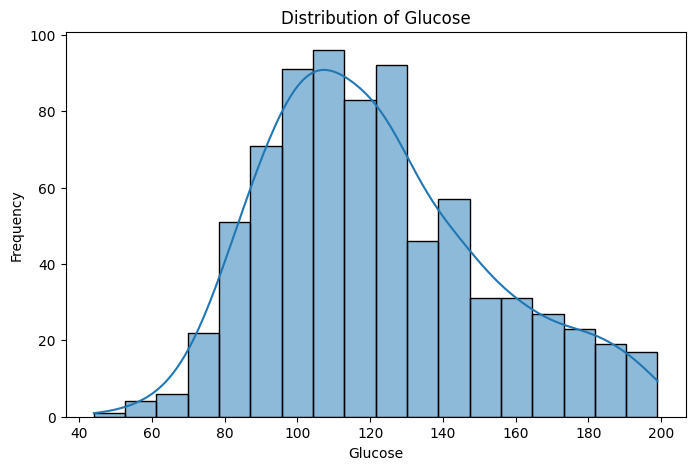

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df[1], kde=True)
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.title("Distribution of Glucose")
plt.show()

# Analyze Blood Pressure Distribution

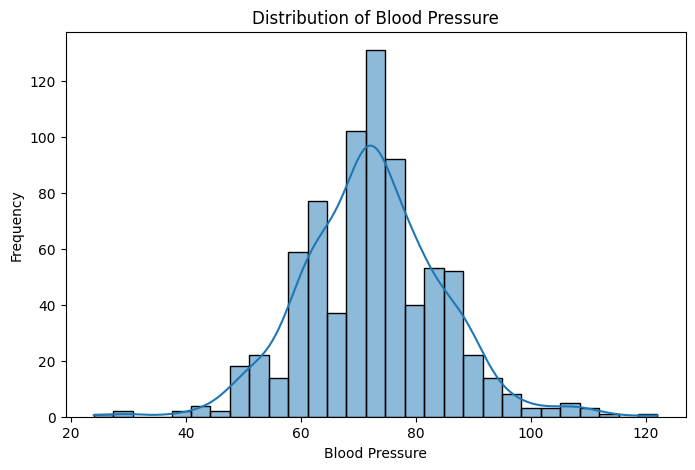

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df[2], kde=True)
plt.xlabel("Blood Pressure")
plt.ylabel("Frequency")
plt.title("Distribution of Blood Pressure")
plt.show()

# Analyze Skin Thickness Distribution

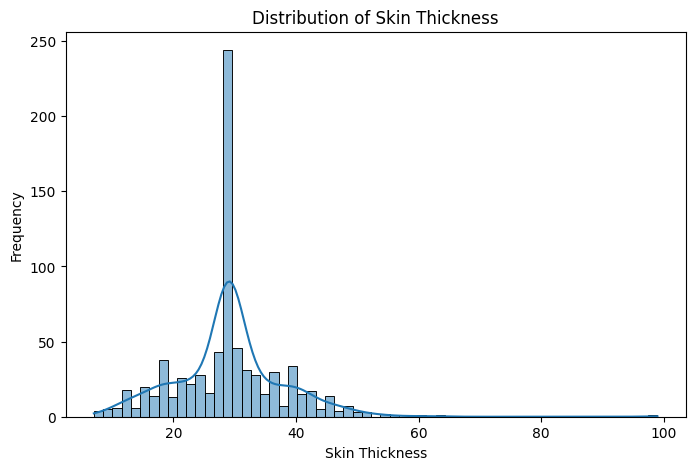

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df[3], kde=True)
plt.xlabel("Skin Thickness")
plt.ylabel("Frequency")
plt.title("Distribution of Skin Thickness")
plt.show()

# Analyze BMI Distribution

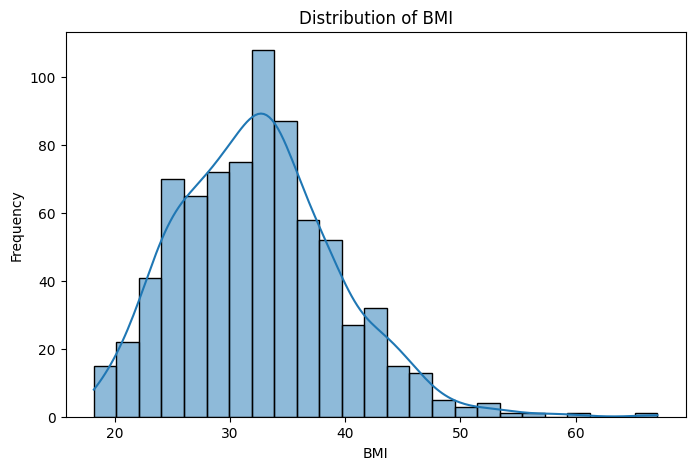

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df[5], kde=True)
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.title("Distribution of BMI")
plt.show()

# Analyze Diabetes Pedigree Function Distribution

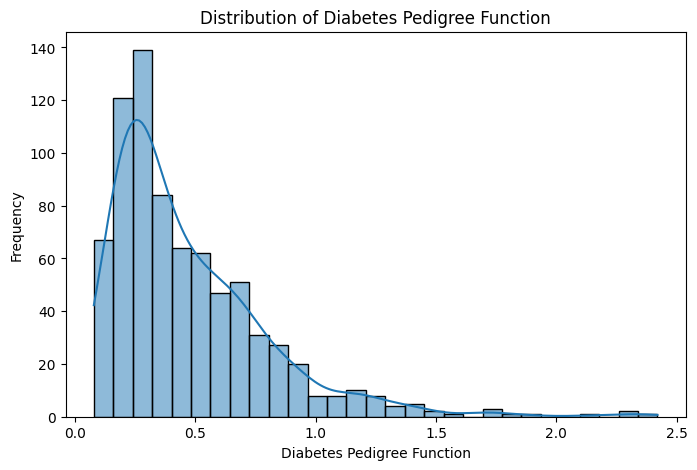

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df[6], kde=True)
plt.xlabel("Diabetes Pedigree Function")
plt.ylabel("Frequency")
plt.title("Distribution of Diabetes Pedigree Function")
plt.show()

# Analyze Age Distribution

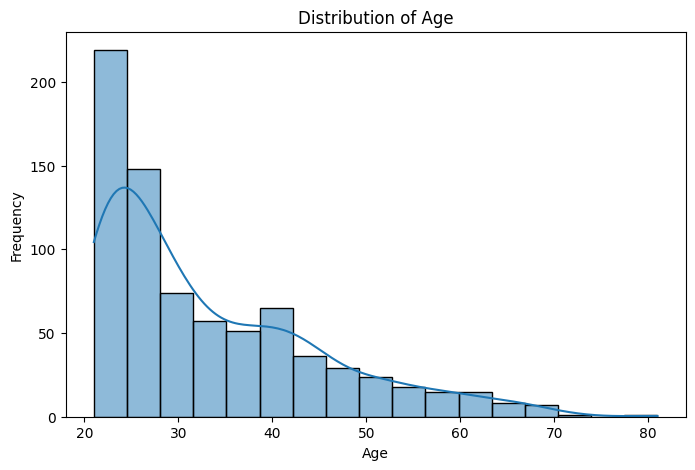

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df[7], kde=True)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.show()

# Analyze Features Against Target

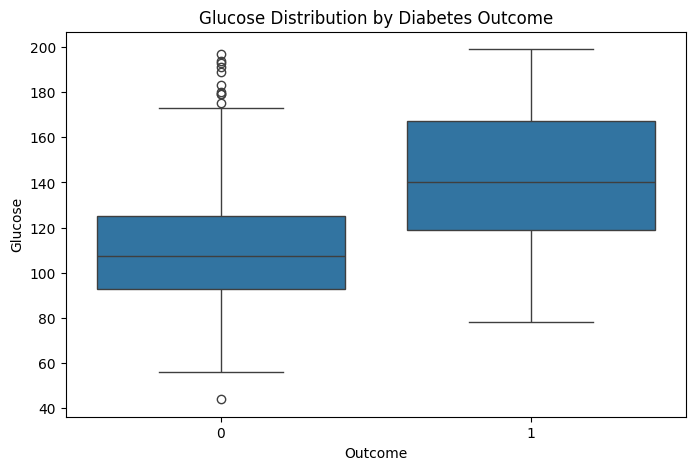

In [ ]:
# Analyze Glucose Against Outcome

plt.figure(figsize=(8, 5))
sns.boxplot(x=df[8], y=df[1])
plt.xlabel("Outcome")
plt.ylabel("Glucose")
plt.title("Glucose Distribution by Diabetes Outcome")
plt.show()

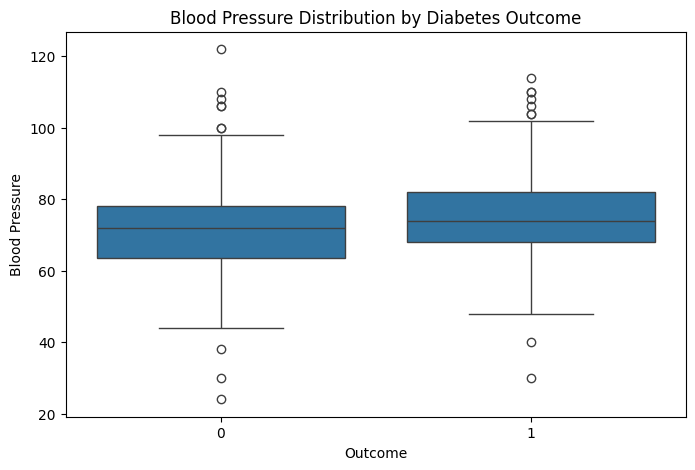

In [ ]:
# Analyze Blood Pressure Against Outcome

plt.figure(figsize=(8, 5))
sns.boxplot(x=df[8], y=df[2])
plt.xlabel("Outcome")
plt.ylabel("Blood Pressure")
plt.title("Blood Pressure Distribution by Diabetes Outcome")
plt.show()

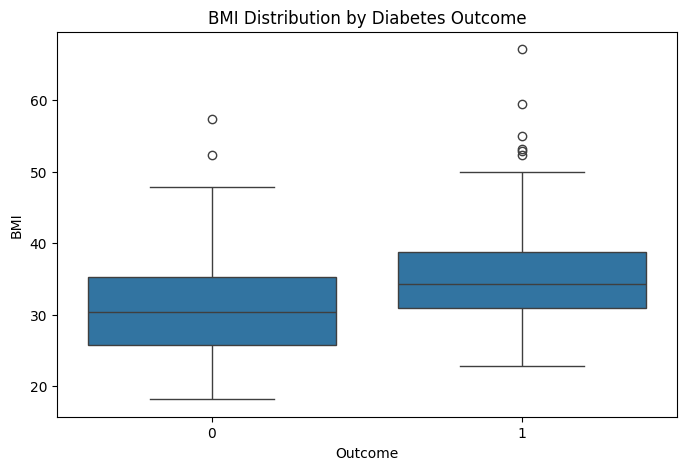

In [ ]:
# Analyze BMI Against Outcome

plt.figure(figsize=(8, 5))
sns.boxplot(x=df[8], y=df[5])
plt.xlabel("Outcome")
plt.ylabel("BMI")
plt.title("BMI Distribution by Diabetes Outcome")
plt.show()

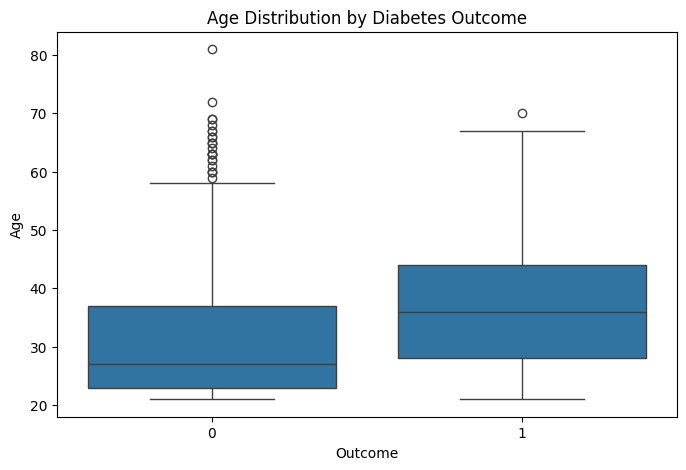

In [ ]:
# Analyze Age Against Outcome

plt.figure(figsize=(8, 5))
sns.boxplot(x=df[8], y=df[7])
plt.xlabel("Outcome")
plt.ylabel("Age")
plt.title("Age Distribution by Diabetes Outcome")
plt.show()

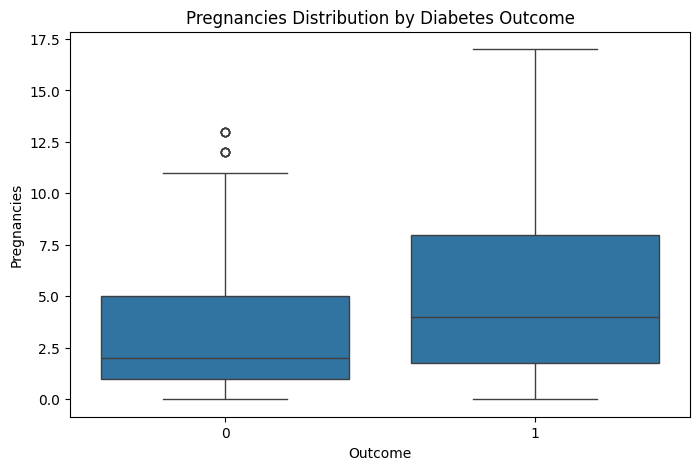

In [ ]:
# Analyze Pregnancies Against Outcome

plt.figure(figsize=(8, 5))
sns.boxplot(x=df[8], y=df[0])
plt.xlabel("Outcome")
plt.ylabel("Pregnancies")
plt.title("Pregnancies Distribution by Diabetes Outcome")
plt.show()

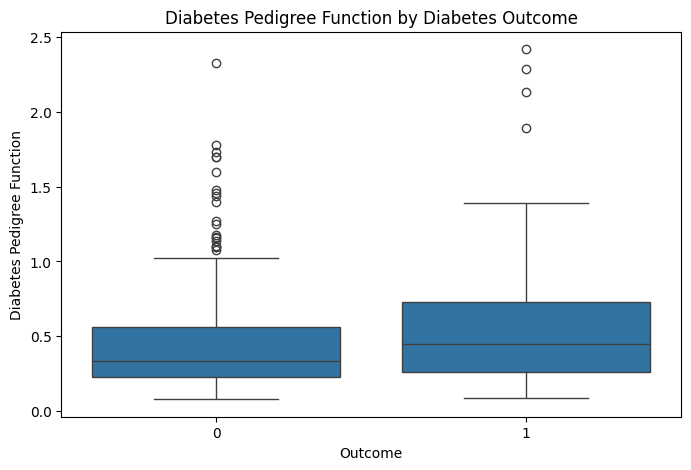

In [ ]:
# Analyze Diabetes Pedigree Function Against Outcome

plt.figure(figsize=(8, 5))
sns.boxplot(x=df[8], y=df[6])
plt.xlabel("Outcome")
plt.ylabel("Diabetes Pedigree Function")
plt.title("Diabetes Pedigree Function by Diabetes Outcome")
plt.show()

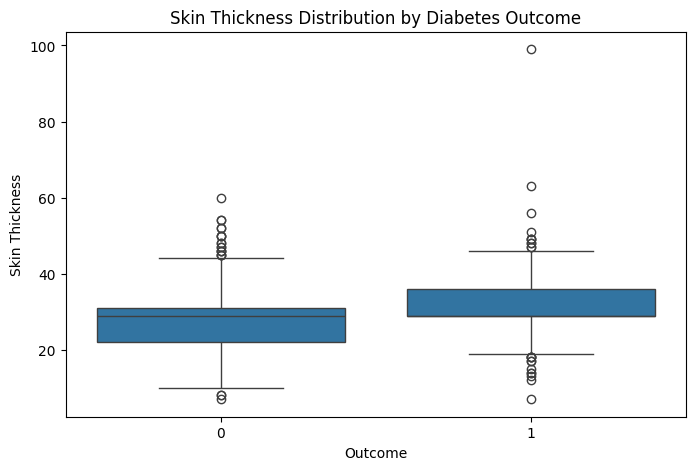

In [ ]:
# Analyze Skin Thickness Against Outcome

plt.figure(figsize=(8, 5))
sns.boxplot(x=df[8], y=df[3])
plt.xlabel("Outcome")
plt.ylabel("Skin Thickness")
plt.title("Skin Thickness Distribution by Diabetes Outcome")
plt.show()

In [ ]:
# Compare Median Skin Thickness by Outcome

df.groupby(8)[3].median()

,3
8,
0,29.0
1,29.0


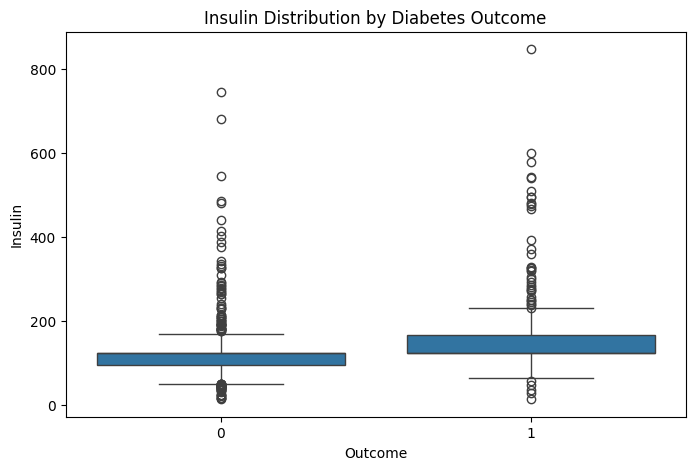

In [ ]:
# Analyze Insulin Against Outcome

plt.figure(figsize=(8, 5))
sns.boxplot(x=df[8], y=df[4])
plt.xlabel("Outcome")
plt.ylabel("Insulin")
plt.title("Insulin Distribution by Diabetes Outcome")
plt.show()

In [ ]:
df.groupby(8)[4].median()

,4
8,
0,125.0
1,125.0


# Compare Feature Means by Outcome

In [ ]:
df.groupby(8).mean()

,0,1,2,3,4,5,6,7
8,,,,,,,,
0,3.298000,110.682000,70.920000,27.726000,127.792000,30.885600,0.429734,31.190000
1,4.865672,142.130597,75.123134,31.686567,164.701493,35.383582,0.550500,37.067164


# Analyze Feature Relationships
### We'll look at how the input features relate to each other, rather than to Outcome.

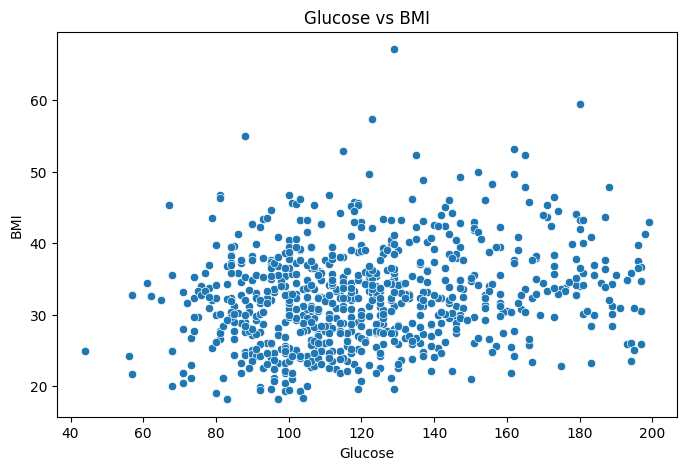

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df[1], y=df[5])
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI")
plt.show()

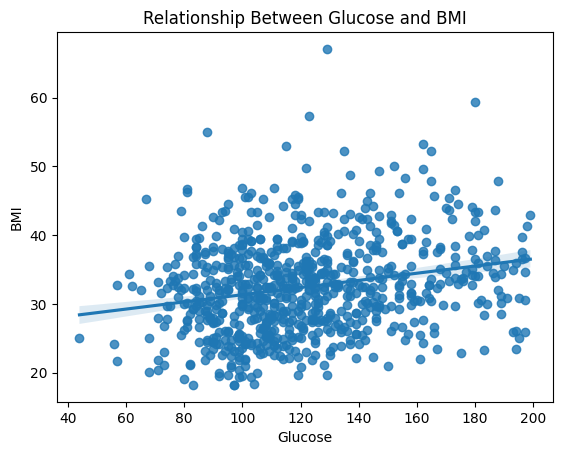

In [ ]:
sns.regplot(x=df[1], y=df[5])
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Relationship Between Glucose and BMI")
plt.show()

In [ ]:
df[1].corr(df[5])

np.float64(0.23104855040238323)

# Analyze Age and Pregnancies Relationship

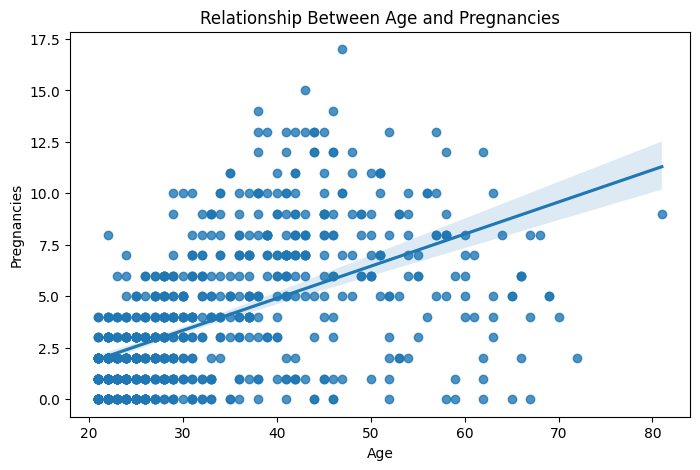

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(x=df[7], y=df[0])
plt.xlabel("Age")
plt.ylabel("Pregnancies")
plt.title("Relationship Between Age and Pregnancies")
plt.show()

In [ ]:
df[7].corr(df[0])

np.float64(0.5443412284023393)

# Analyze All Feature Relationships

In [ ]:
correlation_matrix = df.iloc[:, :8].corr()
correlation_matrix

,0,1,2,3,4,5,6,7
0,1.000000,0.128213,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341
1,0.128213,1.000000,0.218937,0.192615,0.419451,0.231049,0.137327,0.266909
2,0.208615,0.218937,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915
3,0.081770,0.192615,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107
4,0.025047,0.419451,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101
5,0.021559,0.231049,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597
6,-0.033523,0.137327,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561
7,0.544341,0.266909,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000


# Check for Redundant or Highly Related Features

In [ ]:
corr_matrix = df.corr()

high_corr = corr_matrix[(corr_matrix.abs() > 0.7) & (corr_matrix.abs() < 1)]

high_corr

,0,1,2,3,4,5,6,7,8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Final Data Sanity Check

In [ ]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)

Shape: (768, 9)

Missing values:
0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64

Duplicate rows: 0

Data types:
0      int64
1    float64
2    float64
3    float64
4    float64
5    float64
6    float64
7      int64
8      int64
dtype: object


# Give names to our columns

In [ ]:
df.columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


# Step 29 — Separate Features X and Target y

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [ ]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


In [ ]:
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


# Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (614, 8)
X_test: (154, 8)
y_train: (614,)
y_test: (154,)


In [ ]:
y_train.value_counts(normalize=True)

,proportion
Outcome,
0,0.648208
1,0.351792


# Check y_test

In [ ]:
y_test.value_counts(normalize=True)

,proportion
Outcome,
0,0.662338
1,0.337662


# redo the split properly

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (614, 8)
X_test: (154, 8)
y_train: (614,)
y_test: (154,)


# check the new training distribution

In [ ]:
y_train.value_counts(normalize=True)

,proportion
Outcome,
0,0.651466
1,0.348534


# check the test distribution

In [ ]:
y_test.value_counts(normalize=True)

,proportion
Outcome,
0,0.649351
1,0.350649


In [ ]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,614.0,3.819218,3.314148,0.000,1.000,3.0000,6.00000,17.000
Glucose,614.0,121.671010,30.003794,56.000,99.000,117.0000,140.00000,199.000
BloodPressure,614.0,72.140065,12.275119,24.000,64.000,72.0000,80.00000,122.000
SkinThickness,614.0,29.042345,8.891855,7.000,25.000,29.0000,32.00000,99.000
Insulin,614.0,137.705212,78.764767,15.000,120.000,125.0000,130.00000,744.000
BMI,614.0,32.446743,6.824142,18.200,27.625,32.3000,36.50000,67.100
DiabetesPedigreeFunction,614.0,0.477428,0.330300,0.084,0.245,0.3825,0.63925,2.329
Age,614.0,33.366450,11.833438,21.000,24.000,29.0000,41.00000,81.000


# StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

StandardScaler()

# Transform the data

In [ ]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check the scaled data

In [ ]:
print("First 5 rows of scaled training data:")
print(X_train_scaled[:5])

print("\nShape of scaled training data:", X_train_scaled.shape)

print("\nShape of scaled test data:", X_test_scaled.shape)

First 5 rows of scaled training data:
[[-0.85135507 -1.05642747 -0.82674004 -1.91818693 -1.20336073 -0.76947697
   0.31079384 -0.79216928]
 [ 0.35657564  0.14439907  0.47777235 -0.22987447 -1.47019479 -0.41749769
  -0.11643851  0.56103382]
 [-0.5493724  -0.55608308 -1.15286813  1.23332967 -0.55533518  0.3597899
  -0.76486207 -0.70759409]
 [-0.85135507  0.81152492 -1.31593218 -0.00476614 -0.16143729 -0.40283188
   0.26231357 -0.36929331]
 [-1.15333775 -0.88964601 -0.66367599  1.12077551 -0.41556496  1.78237284
  -0.33762972 -0.96131967]]

Shape of scaled training data: (614, 8)

Shape of scaled test data: (154, 8)


In [ ]:
# check the Scaled Data
X_train_scaled.mean(axis=0)

array([-6.94341436e-17, -1.09937394e-16,  3.09560557e-16, -3.47170718e-17,
       -4.33963397e-18, -1.14855646e-15, -1.09937394e-16, -1.08490849e-16])

In [ ]:
# Check the Standard Deviation of Scaled Data

X_train_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1.])

# Start ML Phase


In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

#create the mode
model = LogisticRegression()

# fit the model
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
#Make Predictions on Test Data
y_pred = model.predict(X_test_scaled)

print(y_pred)

[1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 0 0 0 0 1 1 0 0
 0 1 1 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 1 1 0 0 0 0 0 1 0 1 0 1 0 1
 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 1 0]


In [ ]:
print("Number of predictions:", len(y_pred))
print("Number of actual values:", len(y_test))

Number of predictions: 154
Number of actual values: 154


In [ ]:
# check accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7077922077922078


In [ ]:
# confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[82 18]
 [27 27]]


In [ ]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



# ROC-AUC

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.812962962962963


In [ ]:
#prediction probabilities
y_prob = model.predict_proba(X_test_scaled)

print(y_prob[:10])

[[0.39028927 0.60971073]
 [0.88164424 0.11835576]
 [0.70653687 0.29346313]
 [0.7491633  0.2508367 ]
 [0.96679333 0.03320667]
 [0.83147615 0.16852385]
 [0.5118357  0.4881643 ]
 [0.07632489 0.92367511]
 [0.91856595 0.08143405]
 [0.1614104  0.8385896 ]]


In [ ]:
# Extract only class-1 probabilities

y_prob_1 = model.predict_proba(X_test_scaled)[:, 1]

print(y_prob_1[:10])

[0.60971073 0.11835576 0.29346313 0.2508367  0.03320667 0.16852385
 0.4881643  0.92367511 0.08143405 0.8385896 ]


In [ ]:
print("Predicted class distribution:")
print(pd.Series(y_pred).value_counts())

Predicted class distribution:
0    109
1     45
Name: count, dtype: int64


In [ ]:
print("Minimum probability:", y_prob_1.min())
print("Maximum probability:", y_prob_1.max())

Minimum probability: 0.010325580010713086
Maximum probability: 0.9943792634730533


In [ ]:
# compare thresholds
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    predictions = (y_prob_1 >= threshold).astype(int)
    print(
        "Threshold:", threshold,
        "| Predicted 1s:", predictions.sum()
    )

Threshold: 0.3 | Predicted 1s: 72
Threshold: 0.4 | Predicted 1s: 57
Threshold: 0.5 | Predicted 1s: 45
Threshold: 0.6 | Predicted 1s: 39
Threshold: 0.7 | Predicted 1s: 28


In [ ]:
#recall and precision at each threshold
from sklearn.metrics import precision_score, recall_score

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    predictions = (y_prob_1 >= threshold).astype(int)

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)

    print(
        "Threshold:", threshold,
        "| Precision:", round(precision, 2),
        "| Recall:", round(recall, 2)
    )

Threshold: 0.3 | Precision: 0.6 | Recall: 0.8
Threshold: 0.4 | Precision: 0.61 | Recall: 0.65
Threshold: 0.5 | Precision: 0.6 | Recall: 0.5
Threshold: 0.6 | Precision: 0.64 | Recall: 0.46
Threshold: 0.7 | Precision: 0.71 | Recall: 0.37


In [ ]:
#confusion matrix at threshold 0.3
threshold = 0.3

y_pred_03 = (y_prob_1 >= threshold).astype(int)

cm_03 = confusion_matrix(y_test, y_pred_03)

print(cm_03)

[[71 29]
 [11 43]]


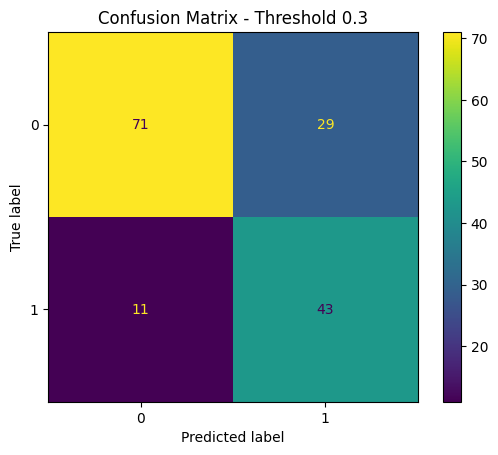

In [ ]:
#visualize the confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_03
)

plt.title("Confusion Matrix - Threshold 0.3")
plt.show()

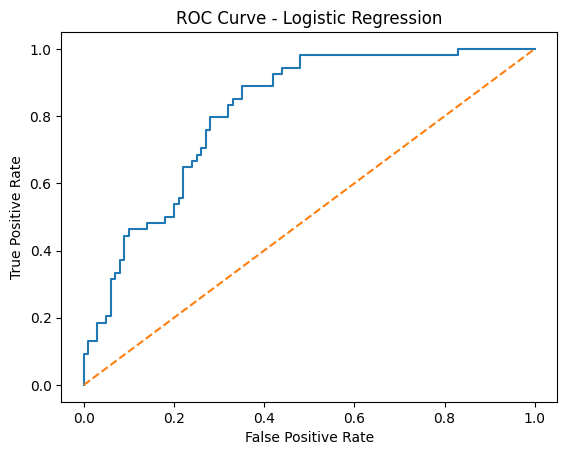

In [ ]:
#visualize the ROC curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_1)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.show()

In [ ]:
#which threshold corresponds to which point on the ROC curve
print("Number of ROC points:", len(thresholds))

print("\nFirst 10 thresholds:")
print(thresholds[:10])

print("\nFirst 10 FPR values:")
print(fpr[:10])

print("\nFirst 10 TPR values:")
print(tpr[:10])

Number of ROC points: 54

First 10 thresholds:
[       inf 0.99437926 0.9119378  0.90645432 0.89481053 0.87813496
 0.85568017 0.8385896  0.81520291 0.81325928]

First 10 FPR values:
[0.   0.   0.   0.01 0.01 0.03 0.03 0.05 0.05 0.06]

First 10 TPR values:
[0.         0.01851852 0.09259259 0.09259259 0.12962963 0.12962963
 0.18518519 0.18518519 0.2037037  0.2037037 ]


In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1-score:", f1)

F1-score: 0.5454545454545454


In [ ]:
#Create baseline results
baseline_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc
}

print(baseline_results)

{'Model': 'Logistic Regression', 'Accuracy': 0.7077922077922078, 'Precision': 0.6, 'Recall': 0.5, 'F1-Score': 0.5454545454545454, 'ROC-AUC': np.float64(0.812962962962963)}


In [ ]:
results_df = pd.DataFrame([baseline_results])

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.6,0.5,0.545455,0.812963


In [ ]:
#Import and create the Decision Tree
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model

DecisionTreeClassifier(random_state=42)

In [ ]:
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Make predictions on the test data
y_pred_tree = tree_model.predict(X_test)

print(y_pred_tree)

[1 0 0 1 1 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 0
 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1 0 0 0 0 0 1 1 1 0 1 1 0 1 1 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 1 1 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 1 0]


In [ ]:
print("Number of predictions:", len(y_pred_tree))
print("Number of actual values:", len(y_test))

Number of predictions: 154
Number of actual values: 154


In [ ]:
# accuracy
from sklearn.metrics import accuracy_score

tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.6818181818181818


In [ ]:
#Confusion Matrix
tree_cm = confusion_matrix(y_test, y_pred_tree)

print(tree_cm)

[[79 21]
 [28 26]]


In [ ]:
#precision, recall, and F1-score
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154



In [ ]:
#ROC-AUC
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

tree_roc_auc = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree ROC-AUC:", tree_roc_auc)

Decision Tree ROC-AUC: 0.6357407407407407


In [ ]:
# — Add Decision Tree to Results Table
tree_results = {
    "Model": "Decision Tree",
    "Accuracy": tree_accuracy,
    "Precision": precision_score(y_test, y_pred_tree),
    "Recall": recall_score(y_test, y_pred_tree),
    "F1-Score": f1_score(y_test, y_pred_tree),
    "ROC-AUC": tree_roc_auc
}

results_df = pd.concat(
    [results_df, pd.DataFrame([tree_results])],
    ignore_index=True
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741


In [ ]:
# Check Tree Depth
print("Tree depth:", tree_model.get_depth())
print("Number of leaves:", tree_model.get_n_leaves())

Tree depth: 14
Number of leaves: 111


In [ ]:
tree_train_accuracy = tree_model.score(X_train, y_train)
tree_test_accuracy = tree_model.score(X_test, y_test)

print("Training Accuracy:", tree_train_accuracy)
print("Test Accuracy:", tree_test_accuracy)

Training Accuracy: 1.0
Test Accuracy: 0.6818181818181818


In [ ]:
tree_model_depth5 = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model_depth5.fit(X_train, y_train)

y_pred_depth5 = tree_model_depth5.predict(X_test)

print("Training Accuracy:", tree_model_depth5.score(X_train, y_train))
print("Test Accuracy:", tree_model_depth5.score(X_test, y_test))

Training Accuracy: 0.8143322475570033
Test Accuracy: 0.7597402597402597


In [ ]:
cm_depth5 = confusion_matrix(y_test, y_pred_depth5)

print(cm_depth5)

[[78 22]
 [15 39]]


In [ ]:
print(classification_report(y_test, y_pred_depth5))

              precision    recall  f1-score   support

           0       0.84      0.78      0.81       100
           1       0.64      0.72      0.68        54

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.76      0.76       154



In [ ]:
y_prob_depth5 = tree_model_depth5.predict_proba(X_test)[:, 1]

depth5_roc_auc = roc_auc_score(y_test, y_prob_depth5)

print("Depth-5 Decision Tree ROC-AUC:", depth5_roc_auc)


Depth-5 Decision Tree ROC-AUC: 0.7622222222222222


In [ ]:
#Add Depth-5 Tree to Results Table
depth5_results = {
    "Model": "Decision Tree (max_depth=5)",
    "Accuracy": tree_model_depth5.score(X_test, y_test),
    "Precision": precision_score(y_test, y_pred_depth5),
    "Recall": recall_score(y_test, y_pred_depth5),
    "F1-Score": f1_score(y_test, y_pred_depth5),
    "ROC-AUC": depth5_roc_auc
}

results_df = pd.concat(
    [results_df, pd.DataFrame([depth5_results])],
    ignore_index=True
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741
2,Decision Tree (max_depth=5),0.759740,0.639344,0.722222,0.678261,0.762222


In [ ]:
#min_samples_leaf
tree_model_leaf5 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

tree_model_leaf5.fit(X_train, y_train)

y_pred_leaf5 = tree_model_leaf5.predict(X_test)

print("Training Accuracy:", tree_model_leaf5.score(X_train, y_train))
print("Test Accuracy:", tree_model_leaf5.score(X_test, y_test))

Training Accuracy: 0.8013029315960912
Test Accuracy: 0.7727272727272727


In [ ]:
#Confusion Matrix for max_depth=5 + min_samples_leaf=5
cm_leaf5 = confusion_matrix(y_test, y_pred_leaf5)

print(cm_leaf5)

[[78 22]
 [13 41]]


In [ ]:
print(classification_report(y_test, y_pred_leaf5))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82       100
           1       0.65      0.76      0.70        54

    accuracy                           0.77       154
   macro avg       0.75      0.77      0.76       154
weighted avg       0.78      0.77      0.78       154



In [ ]:
y_prob_leaf5 = tree_model_leaf5.predict_proba(X_test)[:, 1]

leaf5_roc_auc = roc_auc_score(y_test, y_prob_leaf5)

print("Decision Tree (depth=5, leaf=5) ROC-AUC:", leaf5_roc_auc)

Decision Tree (depth=5, leaf=5) ROC-AUC: 0.7991666666666666


In [ ]:
# Store Leaf-5 Results
leaf5_results = {
    "Model": "Decision Tree (depth=5, leaf=5)",
    "Accuracy": tree_model_leaf5.score(X_test, y_test),
    "Precision": precision_score(y_test, y_pred_leaf5),
    "Recall": recall_score(y_test, y_pred_leaf5),
    "F1-Score": f1_score(y_test, y_pred_leaf5),
    "ROC-AUC": leaf5_roc_auc
}

results_df = pd.concat(
    [results_df, pd.DataFrame([leaf5_results])],
    ignore_index=True
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741
2,Decision Tree (max_depth=5),0.759740,0.639344,0.722222,0.678261,0.762222
3,"Decision Tree (depth=5, leaf=5)",0.772727,0.650794,0.759259,0.700855,0.799167


In [ ]:
from sklearn.model_selection import GridSearchCV
#GridSearchCV = a tool that tests different hyperparameter combinations

In [ ]:
#Define the Parameters to Test
param_grid = {
    "max_depth": [3, 4, 5, 6, 7],
    "min_samples_leaf": [1, 2, 5, 10],
    "min_samples_split": [2, 5, 10]
}

param_grid

{'max_depth': [3, 4, 5, 6, 7],
 'min_samples_leaf': [1, 2, 5, 10],
 'min_samples_split': [2, 5, 10]}

In [ ]:
#Create the GridSearchCV Model
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

dt_grid

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 4, 5, 6, 7],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10]},
             scoring='roc_auc')

In [ ]:
dt_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 4, 5, 6, 7],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10]},
             scoring='roc_auc')

In [ ]:
# Check the Best Parameters

print("Best Parameters:")
print(dt_grid.best_params_)

Best Parameters:
{'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 2}


In [ ]:
#Check Best Cross-Validation ROC-AUC

print("Best Cross-Validation ROC-AUC:")
print(dt_grid.best_score_)

Best Cross-Validation ROC-AUC:
0.78046996124031


In [ ]:
# Get the Best Decision Tree

best_dt = dt_grid.best_estimator_

best_dt

DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)

In [ ]:
#Make Predictions on the Test Set

y_pred_best_dt = best_dt.predict(X_test)

print(y_pred_best_dt)

[1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 1 0 1 0 0 1 0 1 1 0 1 0 1 0 0 0 0 0 0 0 1
 0 0 1 0 0 0 1 0 1 0 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 0 1 0 1 1 0 0 1 0 0 1 1
 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 1 1 1 0 1 1 0 0 1 0 0 1 0 1 0 1 0 0
 1 1 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 1 0]


In [ ]:
#Test Accuracy
best_dt_accuracy = accuracy_score(y_test, y_pred_best_dt)

print("Tuned Decision Tree Accuracy:", best_dt_accuracy)

Tuned Decision Tree Accuracy: 0.7922077922077922


In [ ]:
#Confusion Matrix

best_dt_cm = confusion_matrix(y_test, y_pred_best_dt)

print(best_dt_cm)

[[83 17]
 [15 39]]


In [ ]:
# Classification Report

print(classification_report(y_test, y_pred_best_dt))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       100
           1       0.70      0.72      0.71        54

    accuracy                           0.79       154
   macro avg       0.77      0.78      0.77       154
weighted avg       0.79      0.79      0.79       154



In [ ]:
# ROC-AUC

y_prob_best_dt = best_dt.predict_proba(X_test)[:, 1]

best_dt_roc_auc = roc_auc_score(y_test, y_prob_best_dt)

print("Tuned Decision Tree ROC-AUC:", best_dt_roc_auc)

Tuned Decision Tree ROC-AUC: 0.8006481481481482


In [ ]:
# Add Tuned DT to Our Results Table

tuned_dt_results = {
    "Model": "Decision Tree (GridSearchCV)",
    "Accuracy": best_dt_accuracy,
    "Precision": precision_score(y_test, y_pred_best_dt),
    "Recall": recall_score(y_test, y_pred_best_dt),
    "F1-Score": f1_score(y_test, y_pred_best_dt),
    "ROC-AUC": best_dt_roc_auc
}

results_df = pd.concat(
    [results_df, pd.DataFrame([tuned_dt_results])],
    ignore_index=True
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741
2,Decision Tree (max_depth=5),0.759740,0.639344,0.722222,0.678261,0.762222
3,"Decision Tree (depth=5, leaf=5)",0.772727,0.650794,0.759259,0.700855,0.799167
4,Decision Tree (GridSearchCV),0.792208,0.696429,0.722222,0.709091,0.800648


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model

RandomForestClassifier(random_state=42)

In [ ]:
#Train the Model

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#Make Predictions

y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf)

[1 0 0 0 0 0 1 1 0 1 0 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 1 0 0 0 1 0 1 0 0
 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 1 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0
 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1
 0 0 0 0 1 0]


In [ ]:
# check accuracy

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7792207792207793


In [ ]:
#Confusion Matrix

rf_cm = confusion_matrix(y_test, y_pred_rf)

print(rf_cm)

[[88 12]
 [22 32]]


In [ ]:
# Random Forest Classification Report

rf_report = classification_report(
    y_test,
    y_pred_rf
)

print(rf_report)

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



In [ ]:
# Random Forest ROC-AUC

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", rf_roc_auc)

Random Forest ROC-AUC: 0.8191666666666666


In [ ]:
# Store Results
rf_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": rf_roc_auc
}

results_df = pd.concat(
    [results_df, pd.DataFrame([rf_results])],
    ignore_index=True
)

results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741
2,Decision Tree (max_depth=5),0.759740,0.639344,0.722222,0.678261,0.762222
3,"Decision Tree (depth=5, leaf=5)",0.772727,0.650794,0.759259,0.700855,0.799167
4,Decision Tree (GridSearchCV),0.792208,0.696429,0.722222,0.709091,0.800648
5,Random Forest,0.779221,0.727273,0.592593,0.653061,0.819167


In [ ]:
# Random Forest Training vs Test Accuracy

rf_train_accuracy = rf_model.score(X_train, y_train)
rf_test_accuracy = rf_model.score(X_test, y_test)

print("Training Accuracy:", rf_train_accuracy)
print("Test Accuracy:", rf_test_accuracy)

Training Accuracy: 1.0
Test Accuracy: 0.7792207792207793


In [ ]:
# Random Forest hyperparameter grid :We need to tell GridSearchCV which Random Forest settings it should try

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

rf_param_grid

{'n_estimators': [100, 200, 300],
 'max_depth': [None, 5, 10, 15],
 'min_samples_split': [2, 5, 10],
 'min_samples_leaf': [1, 2, 5]}

In [ ]:
# Create GridSearchCV for Random Forest

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc')

In [ ]:
# Run GridSearchCV on the training data

rf_grid.fit(X_train, y_train)

print("GridSearchCV completed.")

GridSearchCV completed.


In [ ]:
# Best Random Forest parameters

print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(rf_grid.best_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 300}

Best Cross-Validation ROC-AUC:
0.8406935215946844


In [ ]:
# Get the best Random Forest model

best_rf = rf_grid.best_estimator_

print(best_rf)

RandomForestClassifier(max_depth=5, min_samples_leaf=5, n_estimators=300,
                       random_state=42)


In [ ]:
# Predictions from the tuned Random Forest

y_pred_best_rf = best_rf.predict(X_test)

print(y_pred_best_rf)

[1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0 1 1 0 0
 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 1 1 0 0 0 0 0 1 0 1 0 1 0 0
 1 1 1 0 0 0 0 1 0 1 0 0 0 0 1 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 1 0]


In [ ]:
# Accuracy of the tuned Random Forest

best_rf_accuracy = accuracy_score(y_test, y_pred_best_rf)

print("Tuned Random Forest Accuracy:", best_rf_accuracy)

Tuned Random Forest Accuracy: 0.7402597402597403


In [ ]:
# Confusion matrix for the tuned Random Forest

best_rf_cm = confusion_matrix(
    y_test,
    y_pred_best_rf
)

print(best_rf_cm)

[[86 14]
 [26 28]]


In [ ]:
# Classification report for the tuned Random Forest

best_rf_report = classification_report(
    y_test,
    y_pred_best_rf
)

print(best_rf_report)

              precision    recall  f1-score   support

           0       0.77      0.86      0.81       100
           1       0.67      0.52      0.58        54

    accuracy                           0.74       154
   macro avg       0.72      0.69      0.70       154
weighted avg       0.73      0.74      0.73       154



In [ ]:
# ROC-AUC of the tuned Random Forest

y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

best_rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_best_rf
)

print("Tuned Random Forest ROC-AUC:", best_rf_roc_auc)

Tuned Random Forest ROC-AUC: 0.8066666666666666


In [ ]:
# Store tuned Random Forest results

tuned_rf_results = {
    "Model": "Random Forest (GridSearchCV)",
    "Accuracy": best_rf_accuracy,
    "Precision": precision_score(y_test, y_pred_best_rf),
    "Recall": recall_score(y_test, y_pred_best_rf),
    "F1-Score": f1_score(y_test, y_pred_best_rf),
    "ROC-AUC": best_rf_roc_auc
}

results_df = pd.concat(
    [results_df, pd.DataFrame([tuned_rf_results])],
    ignore_index=True
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741
2,Decision Tree (max_depth=5),0.759740,0.639344,0.722222,0.678261,0.762222
3,"Decision Tree (depth=5, leaf=5)",0.772727,0.650794,0.759259,0.700855,0.799167
4,Decision Tree (GridSearchCV),0.792208,0.696429,0.722222,0.709091,0.800648
5,Random Forest,0.779221,0.727273,0.592593,0.653061,0.819167
6,Random Forest (GridSearchCV),0.740260,0.666667,0.518519,0.583333,0.806667


# Support Vector Machine (SVM)

In [ ]:
# Create the SVM model

from sklearn.svm import SVC

svm_model = SVC(
    random_state=42,
    probability=True
)

svm_model

SVC(probability=True, random_state=42)

In [ ]:
# Train the SVM model

svm_model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [ ]:
# Train the SVM model

svm_model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [ ]:
# Make predictions on the test data

y_pred_svm = svm_model.predict(X_test_scaled)

print(y_pred_svm)

[1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0 1 1 0 0
 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 1 1 1 0 0 0 0 0 1 0 1 0 1 0 0
 1 1 0 0 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1
 0 0 0 0 1 0]


In [ ]:
# Calculate SVM accuracy

from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.7402597402597403


In [ ]:
# Create the confusion matrix

from sklearn.metrics import confusion_matrix

svm_cm = confusion_matrix(
    y_test,
    y_pred_svm
)

print(svm_cm)

[[84 16]
 [24 30]]


In [ ]:
# Generate the classification report

from sklearn.metrics import classification_report

svm_report = classification_report(
    y_test,
    y_pred_svm
)

print(svm_report)

              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



In [ ]:
# Calculate SVM ROC-AUC

from sklearn.metrics import roc_auc_score

y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

svm_roc_auc = roc_auc_score(
    y_test,
    y_prob_svm
)

print("SVM ROC-AUC:", svm_roc_auc)

SVM ROC-AUC: 0.7963888888888889


In [ ]:
# Store SVM results

svm_results = {
    "Model": "SVM",
    "Accuracy": svm_accuracy,
    "Precision": precision_score(y_test, y_pred_svm),
    "Recall": recall_score(y_test, y_pred_svm),
    "F1-Score": f1_score(y_test, y_pred_svm),
    "ROC-AUC": svm_roc_auc
}

results_df = pd.concat(
    [results_df, pd.DataFrame([svm_results])],
    ignore_index=True
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741
2,Decision Tree (max_depth=5),0.759740,0.639344,0.722222,0.678261,0.762222
3,"Decision Tree (depth=5, leaf=5)",0.772727,0.650794,0.759259,0.700855,0.799167
4,Decision Tree (GridSearchCV),0.792208,0.696429,0.722222,0.709091,0.800648
5,Random Forest,0.779221,0.727273,0.592593,0.653061,0.819167
6,Random Forest (GridSearchCV),0.740260,0.666667,0.518519,0.583333,0.806667
7,SVM,0.740260,0.652174,0.555556,0.600000,0.796389


In [ ]:
# Compare training and test accuracy

svm_train_accuracy = svm_model.score(
    X_train_scaled,
    y_train
)

svm_test_accuracy = svm_model.score(
    X_test_scaled,
    y_test
)

print("Training Accuracy:", svm_train_accuracy)
print("Test Accuracy:", svm_test_accuracy)

Training Accuracy: 0.8403908794788274
Test Accuracy: 0.7402597402597403


In [ ]:
# Define parameters for SVM tuning

svm_param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1],
    "kernel": ["rbf", "linear"]
}

svm_param_grid

{'C': [0.1, 1, 10, 100],
 'gamma': ['scale', 'auto', 0.01, 0.1, 1],
 'kernel': ['rbf', 'linear']}

In [ ]:
# Create GridSearchCV for SVM

from sklearn.model_selection import GridSearchCV

svm_grid = GridSearchCV(
    estimator=SVC(
        random_state=42,
        probability=True
    ),
    param_grid=svm_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

svm_grid

GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.01, 0.1, 1],
                         'kernel': ['rbf', 'linear']},
             scoring='roc_auc')

In [ ]:
# Run GridSearchCV

svm_grid.fit(X_train_scaled, y_train)

print("GridSearchCV completed.")

GridSearchCV completed.


In [ ]:
# Check the best SVM parameters

print("Best Parameters:")
print(svm_grid.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(svm_grid.best_score_)

Best Parameters:
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

Best Cross-Validation ROC-AUC:
0.842955426356589


In [ ]:
# Get the best SVM model

best_svm = svm_grid.best_estimator_

print(best_svm)

SVC(C=10, gamma=0.01, probability=True, random_state=42)


In [ ]:
# Make predictions with the tuned SVM

y_pred_best_svm = best_svm.predict(X_test_scaled)

print(y_pred_best_svm)

[1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 1 1 0 1 0 0 0 0 0 1 1 1 0 0
 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 1 1 0 0 0 0 0 1 0 1 0 1 0 1
 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 1 0]


In [ ]:
# Calculate tuned SVM accuracy

best_svm_accuracy = accuracy_score(
    y_test,
    y_pred_best_svm
)

print("Tuned SVM Accuracy:", best_svm_accuracy)

Tuned SVM Accuracy: 0.6948051948051948


In [ ]:
# Create confusion matrix for tuned SVM

best_svm_cm = confusion_matrix(
    y_test,
    y_pred_best_svm
)

print(best_svm_cm)

[[82 18]
 [29 25]]


In [ ]:
# Classification report for tuned SVM

best_svm_report = classification_report(
    y_test,
    y_pred_best_svm
)

print(best_svm_report)

              precision    recall  f1-score   support

           0       0.74      0.82      0.78       100
           1       0.58      0.46      0.52        54

    accuracy                           0.69       154
   macro avg       0.66      0.64      0.65       154
weighted avg       0.68      0.69      0.69       154



In [ ]:
# Calculate ROC-AUC for tuned SVM

y_prob_best_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

best_svm_roc_auc = roc_auc_score(
    y_test,
    y_prob_best_svm
)

print("Tuned SVM ROC-AUC:", best_svm_roc_auc)

Tuned SVM ROC-AUC: 0.8150925925925926


In [ ]:
# Store tuned SVM results

tuned_svm_results = {
    "Model": "SVM (GridSearchCV)",
    "Accuracy": best_svm_accuracy,
    "Precision": precision_score(y_test, y_pred_best_svm),
    "Recall": recall_score(y_test, y_pred_best_svm),
    "F1-Score": f1_score(y_test, y_pred_best_svm),
    "ROC-AUC": best_svm_roc_auc
}

results_df = pd.concat(
    [results_df, pd.DataFrame([tuned_svm_results])],
    ignore_index=True
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741
2,Decision Tree (max_depth=5),0.759740,0.639344,0.722222,0.678261,0.762222
3,"Decision Tree (depth=5, leaf=5)",0.772727,0.650794,0.759259,0.700855,0.799167
4,Decision Tree (GridSearchCV),0.792208,0.696429,0.722222,0.709091,0.800648
5,Random Forest,0.779221,0.727273,0.592593,0.653061,0.819167
6,Random Forest (GridSearchCV),0.740260,0.666667,0.518519,0.583333,0.806667
7,SVM,0.740260,0.652174,0.555556,0.600000,0.796389
8,SVM (GridSearchCV),0.694805,0.581395,0.462963,0.515464,0.815093


# K-Nearest Neighbours (KNN)

In [ ]:
# Create the KNN model

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model

KNeighborsClassifier()

In [ ]:
# Train the KNN model

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
# Make predictions on the test data

y_pred_knn = knn_model.predict(X_test_scaled)

print(y_pred_knn)

[1 0 0 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0 1 1 0 0
 0 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 1 0 1 0 1 1 1
 1 1 0 0 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 1 0
 0 0 0 0 1 0]


In [ ]:
# Calculate KNN accuracy

knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.7532467532467533


In [ ]:
# Create the KNN confusion matrix

knn_cm = confusion_matrix(
    y_test,
    y_pred_knn
)

print(knn_cm)

[[83 17]
 [21 33]]


In [ ]:
# Generate the KNN classification report

knn_report = classification_report(
    y_test,
    y_pred_knn
)

print(knn_report)

              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [ ]:
# Get probability of class 1 (diabetes)

y_prob_knn = knn_model.predict_proba(
    X_test_scaled
)[:, 1]

# Calculate ROC-AUC

knn_roc_auc = roc_auc_score(
    y_test,
    y_prob_knn
)

print("KNN ROC-AUC:", knn_roc_auc)

KNN ROC-AUC: 0.7886111111111112


In [ ]:
#save results

knn_results = {
    "Model": "KNN",
    "Accuracy": knn_accuracy,
    "Precision": precision_score(y_test, y_pred_knn),
    "Recall": recall_score(y_test, y_pred_knn),
    "F1-Score": f1_score(y_test, y_pred_knn),
    "ROC-AUC": knn_roc_auc
}

results_df = pd.concat(
    [results_df, pd.DataFrame([knn_results])],
    ignore_index=True
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741
2,Decision Tree (max_depth=5),0.759740,0.639344,0.722222,0.678261,0.762222
3,"Decision Tree (depth=5, leaf=5)",0.772727,0.650794,0.759259,0.700855,0.799167
4,Decision Tree (GridSearchCV),0.792208,0.696429,0.722222,0.709091,0.800648
5,Random Forest,0.779221,0.727273,0.592593,0.653061,0.819167
6,Random Forest (GridSearchCV),0.740260,0.666667,0.518519,0.583333,0.806667
7,SVM,0.740260,0.652174,0.555556,0.600000,0.796389
8,SVM (GridSearchCV),0.694805,0.581395,0.462963,0.515464,0.815093
9,KNN,0.753247,0.660000,0.611111,0.634615,0.788611


In [ ]:
# check overfitting
knn_train_accuracy = knn_model.score(
    X_train_scaled,
    y_train
)

knn_test_accuracy = knn_model.score(
    X_test_scaled,
    y_test
)

print("Training Accuracy:", knn_train_accuracy)
print("Test Accuracy:", knn_test_accuracy)

Training Accuracy: 0.8306188925081434
Test Accuracy: 0.7532467532467533


In [ ]:
#KNN tuning

knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn_param_grid

{'n_neighbors': [3, 5, 7, 9, 11, 15],
 'weights': ['uniform', 'distance'],
 'metric': ['euclidean', 'manhattan']}

In [ ]:
# Grid Search cv for knn

knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

knn_grid

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11, 15],
                         'weights': ['uniform', 'distance']},
             scoring='roc_auc')

In [ ]:
# Run GridSearchCV on the training data

knn_grid.fit(
    X_train_scaled,
    y_train
)

print("GridSearchCV completed.")

GridSearchCV completed.


In [ ]:
# Get the best KNN parameters

print("Best Parameters:")
print(knn_grid.best_params_)

# Get the best cross-validation ROC-AUC

print("\nBest Cross-Validation ROC-AUC:")
print(knn_grid.best_score_)

Best Parameters:
{'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}

Best Cross-Validation ROC-AUC:
0.8266431339977853


In [ ]:
# Get the best KNN model from GridSearchCV

best_knn = knn_grid.best_estimator_

# Display the best model

print(best_knn)

KNeighborsClassifier(metric='euclidean', n_neighbors=15)


In [ ]:
# Make predictions using the tuned KNN model

y_pred_best_knn = best_knn.predict(
    X_test_scaled
)

print(y_pred_best_knn)

[1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0 1 1 0 0
 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 1 1 1 0 0 0 0 0 1 0 1 0 1 1 0
 1 1 0 0 0 0 0 1 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 1 0 0 0 1 0]


In [ ]:
# Calculate tuned KNN test accuracy

best_knn_accuracy = accuracy_score(
    y_test,
    y_pred_best_knn
)

print("Tuned KNN Accuracy:", best_knn_accuracy)

Tuned KNN Accuracy: 0.7402597402597403


In [ ]:
# Calculate the confusion matrix for tuned KNN

best_knn_cm = confusion_matrix(
    y_test,
    y_pred_best_knn
)

print(best_knn_cm)

[[84 16]
 [24 30]]


In [ ]:
# Generate the classification report for tuned KNN

print(
    classification_report(
        y_test,
        y_pred_best_knn
    )
)


              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



In [ ]:
# Get probability of class 1 (diabetes)

y_prob_best_knn = best_knn.predict_proba(
    X_test_scaled
)[:, 1]

# Calculate tuned KNN ROC-AUC

best_knn_roc_auc = roc_auc_score(
    y_test,
    y_prob_best_knn
)

print("Tuned KNN ROC-AUC:", best_knn_roc_auc)

Tuned KNN ROC-AUC: 0.8067592592592593


In [ ]:
# Store tuned KNN results

tuned_knn_results = {
    "Model": "KNN (GridSearchCV)",
    "Accuracy": best_knn_accuracy,
    "Precision": precision_score(
        y_test,
        y_pred_best_knn
    ),
    "Recall": recall_score(
        y_test,
        y_pred_best_knn
    ),
    "F1-Score": f1_score(
        y_test,
        y_pred_best_knn
    ),
    "ROC-AUC": best_knn_roc_auc
}

# Add tuned KNN results to the results table

results_df = pd.concat(
    [results_df, pd.DataFrame([tuned_knn_results])],
    ignore_index=True
)

# Display all model results

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741
2,Decision Tree (max_depth=5),0.759740,0.639344,0.722222,0.678261,0.762222
3,"Decision Tree (depth=5, leaf=5)",0.772727,0.650794,0.759259,0.700855,0.799167
4,Decision Tree (GridSearchCV),0.792208,0.696429,0.722222,0.709091,0.800648
5,Random Forest,0.779221,0.727273,0.592593,0.653061,0.819167
6,Random Forest (GridSearchCV),0.740260,0.666667,0.518519,0.583333,0.806667
7,SVM,0.740260,0.652174,0.555556,0.600000,0.796389
8,SVM (GridSearchCV),0.694805,0.581395,0.462963,0.515464,0.815093
9,KNN,0.753247,0.660000,0.611111,0.634615,0.788611


In [ ]:
# Calculate tuned KNN training accuracy

best_knn_train_accuracy = best_knn.score(
    X_train_scaled,
    y_train
)

# Calculate tuned KNN test accuracy

best_knn_test_accuracy = best_knn.score(
    X_test_scaled,
    y_test
)

print("Training Accuracy:", best_knn_train_accuracy)
print("Test Accuracy:", best_knn_test_accuracy)

Training Accuracy: 0.8029315960912052
Test Accuracy: 0.7402597402597403


# XGBoost

In [ ]:
# Import XGBoost classifier

from xgboost import XGBClassifier

# Create the XGBoost model

xgb_model = XGBClassifier(
    random_state=42
)

# Display the model

xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Train the XGBoost model

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [ ]:
# Make predictions using the XGBoost model

y_pred_xgb = xgb_model.predict(
    X_test
)

print(y_pred_xgb)

[1 0 0 0 0 1 0 1 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0
 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 0 1 0 1 1 0 0 1 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 1 0 1 0 0
 1 1 1 0 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1
 0 0 0 0 1 0]


In [ ]:
# Calculate XGBoost test accuracy

xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.7727272727272727


In [ ]:
# Calculate the confusion matrix for XGBoost

xgb_cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

print(xgb_cm)

[[86 14]
 [21 33]]


In [ ]:
# Generate the XGBoost classification report

print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.80      0.86      0.83       100
           1       0.70      0.61      0.65        54

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154



In [ ]:
# Get probability of class 1 (diabetes)

y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:, 1]

# Calculate XGBoost ROC-AUC

xgb_roc_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("XGBoost ROC-AUC:", xgb_roc_auc)

XGBoost ROC-AUC: 0.8153703703703704


In [ ]:
# Store XGBoost results

xgb_results = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": precision_score(
        y_test,
        y_pred_xgb
    ),
    "Recall": recall_score(
        y_test,
        y_pred_xgb
    ),
    "F1-Score": f1_score(
        y_test,
        y_pred_xgb
    ),
    "ROC-AUC": xgb_roc_auc
}

# Add XGBoost results to the results table

results_df = pd.concat(
    [results_df, pd.DataFrame([xgb_results])],
    ignore_index=True
)

# Display the updated results

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741
2,Decision Tree (max_depth=5),0.759740,0.639344,0.722222,0.678261,0.762222
3,"Decision Tree (depth=5, leaf=5)",0.772727,0.650794,0.759259,0.700855,0.799167
4,Decision Tree (GridSearchCV),0.792208,0.696429,0.722222,0.709091,0.800648
5,Random Forest,0.779221,0.727273,0.592593,0.653061,0.819167
6,Random Forest (GridSearchCV),0.740260,0.666667,0.518519,0.583333,0.806667
7,SVM,0.740260,0.652174,0.555556,0.600000,0.796389
8,SVM (GridSearchCV),0.694805,0.581395,0.462963,0.515464,0.815093
9,KNN,0.753247,0.660000,0.611111,0.634615,0.788611


In [ ]:
# Calculate XGBoost training accuracy

xgb_train_accuracy = xgb_model.score(
    X_train,
    y_train
)

# Calculate XGBoost test accuracy

xgb_test_accuracy = xgb_model.score(
    X_test,
    y_test
)

print("Training Accuracy:", xgb_train_accuracy)
print("Test Accuracy:", xgb_test_accuracy)

Training Accuracy: 1.0
Test Accuracy: 0.7727272727272727


In [ ]:
# Define XGBoost hyperparameters to test

xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

In [ ]:
# Create GridSearchCV for XGBoost

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42
    ),
    param_grid=xgb_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Display the GridSearchCV object

xgb_grid

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [2, 3, 4],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='roc_auc')

In [ ]:
# Run GridSearchCV on the training data

xgb_grid.fit(
    X_train,
    y_train
)

print("GridSearchCV completed.")

GridSearchCV completed.


In [ ]:
# Display the best XGBoost parameters

print("Best Parameters:")
print(xgb_grid.best_params_)

# Display the best cross-validation ROC-AUC

print("\nBest Cross-Validation ROC-AUC:")
print(xgb_grid.best_score_)


Best Parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}

Best Cross-Validation ROC-AUC:
0.8381990586932447


In [ ]:
# Get the best XGBoost model found by GridSearchCV

best_xgb = xgb_grid.best_estimator_

# Display the best model

print(best_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)


In [ ]:
# Make predictions using the tuned XGBoost model

y_pred_best_xgb = best_xgb.predict(
    X_test
)

print(y_pred_best_xgb)

[1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 0 0 0 0 1 1 0 0
 0 1 1 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 1 0 1 0 1 0 0
 1 1 1 0 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 1 0]


In [ ]:
# Calculate tuned XGBoost test accuracy

best_xgb_accuracy = accuracy_score(
    y_test,
    y_pred_best_xgb
)

print("Tuned XGBoost Accuracy:", best_xgb_accuracy)

Tuned XGBoost Accuracy: 0.7272727272727273


In [ ]:
# Calculate the confusion matrix for tuned XGBoost

best_xgb_cm = confusion_matrix(
    y_test,
    y_pred_best_xgb
)

print(best_xgb_cm)

[[83 17]
 [25 29]]


In [ ]:
# Generate the classification report for tuned XGBoost

print(
    classification_report(
        y_test,
        y_pred_best_xgb
    )
)

              precision    recall  f1-score   support

           0       0.77      0.83      0.80       100
           1       0.63      0.54      0.58        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.69       154
weighted avg       0.72      0.73      0.72       154



In [ ]:
# Get probability of class 1 (diabetes)

y_prob_best_xgb = best_xgb.predict_proba(
    X_test
)[:, 1]

# Calculate tuned XGBoost ROC-AUC

best_xgb_roc_auc = roc_auc_score(
    y_test,
    y_prob_best_xgb
)

print("Tuned XGBoost ROC-AUC:", best_xgb_roc_auc)

Tuned XGBoost ROC-AUC: 0.8144444444444444


In [ ]:
# Store tuned XGBoost results

tuned_xgb_results = {
    "Model": "XGBoost (GridSearchCV)",
    "Accuracy": best_xgb_accuracy,
    "Precision": precision_score(
        y_test,
        y_pred_best_xgb
    ),
    "Recall": recall_score(
        y_test,
        y_pred_best_xgb
    ),
    "F1-Score": f1_score(
        y_test,
        y_pred_best_xgb
    ),
    "ROC-AUC": best_xgb_roc_auc
}

# Add tuned XGBoost results to the results table

results_df = pd.concat(
    [results_df, pd.DataFrame([tuned_xgb_results])],
    ignore_index=True
)

# Display the updated results

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741
2,Decision Tree (max_depth=5),0.759740,0.639344,0.722222,0.678261,0.762222
3,"Decision Tree (depth=5, leaf=5)",0.772727,0.650794,0.759259,0.700855,0.799167
4,Decision Tree (GridSearchCV),0.792208,0.696429,0.722222,0.709091,0.800648
5,Random Forest,0.779221,0.727273,0.592593,0.653061,0.819167
6,Random Forest (GridSearchCV),0.740260,0.666667,0.518519,0.583333,0.806667
7,SVM,0.740260,0.652174,0.555556,0.600000,0.796389
8,SVM (GridSearchCV),0.694805,0.581395,0.462963,0.515464,0.815093
9,KNN,0.753247,0.660000,0.611111,0.634615,0.788611


In [ ]:
# Calculate tuned XGBoost training accuracy

best_xgb_train_accuracy = best_xgb.score(
    X_train,
    y_train
)

# Calculate tuned XGBoost test accuracy

best_xgb_test_accuracy = best_xgb.score(
    X_test,
    y_test
)

print("Training Accuracy:", best_xgb_train_accuracy)
print("Test Accuracy:", best_xgb_test_accuracy)

Training Accuracy: 0.8192182410423453
Test Accuracy: 0.7272727272727273


#AdaBoost

In [ ]:
# Import AdaBoost classifier

from sklearn.ensemble import AdaBoostClassifier

# Create the AdaBoost model

ada_model = AdaBoostClassifier(
    random_state=42
)

# Display the model

ada_model

AdaBoostClassifier(random_state=42)

In [ ]:
# Train the AdaBoost model

ada_model.fit(
    X_train,
    y_train
)

print("AdaBoost model trained successfully.")

AdaBoost model trained successfully.


In [ ]:
# Make predictions using the AdaBoost model

y_pred_ada = ada_model.predict(
    X_test
)

print(y_pred_ada)

[1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 0 0 0 1 0 1 0 0
 0 1 1 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0
 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0 0 0 1 0 1 0 1 0 0
 1 0 1 0 0 0 0 1 0 1 0 0 0 0 1 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 1
 0 0 0 0 1 0]


In [ ]:
# Calculate AdaBoost test accuracy

ada_accuracy = accuracy_score(
    y_test,
    y_pred_ada
)

print("AdaBoost Accuracy:", ada_accuracy)

AdaBoost Accuracy: 0.7467532467532467


In [ ]:
# Calculate the confusion matrix for AdaBoost

ada_cm = confusion_matrix(
    y_test,
    y_pred_ada
)

print(ada_cm)

[[84 16]
 [23 31]]


In [ ]:
# Generate the classification report for AdaBoost

print(
    classification_report(
        y_test,
        y_pred_ada
    )
)

              precision    recall  f1-score   support

           0       0.79      0.84      0.81       100
           1       0.66      0.57      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.74      0.75      0.74       154



In [ ]:
# Get probability of class 1 (diabetes)

y_prob_ada = ada_model.predict_proba(
    X_test
)[:, 1]

# Calculate AdaBoost ROC-AUC

ada_roc_auc = roc_auc_score(
    y_test,
    y_prob_ada
)

print("AdaBoost ROC-AUC:", ada_roc_auc)

AdaBoost ROC-AUC: 0.817962962962963


In [ ]:
# Calculate AdaBoost training accuracy

ada_train_accuracy = ada_model.score(
    X_train,
    y_train
)

# Calculate AdaBoost test accuracy

ada_test_accuracy = ada_model.score(
    X_test,
    y_test
)

print("Training Accuracy:", ada_train_accuracy)
print("Test Accuracy:", ada_test_accuracy)

Training Accuracy: 0.8175895765472313
Test Accuracy: 0.7467532467532467


In [ ]:
# Define AdaBoost hyperparameters to test

ada_param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0]
}

In [ ]:
# Create GridSearchCV for AdaBoost

ada_grid = GridSearchCV(
    estimator=AdaBoostClassifier(
        random_state=42
    ),
    param_grid=ada_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Display the GridSearchCV object

ada_grid

GridSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
                         'n_estimators': [50, 100, 200, 300]},
             scoring='roc_auc')

In [ ]:
# Run GridSearchCV on the training data

ada_grid.fit(
    X_train,
    y_train
)

print("GridSearchCV completed.")

GridSearchCV completed.


In [ ]:
# Display the best AdaBoost parameters

print("Best Parameters:")
print(ada_grid.best_params_)

# Display the best cross-validation ROC-AUC

print("\nBest Cross-Validation ROC-AUC:")
print(ada_grid.best_score_)

Best Parameters:
{'learning_rate': 0.5, 'n_estimators': 100}

Best Cross-Validation ROC-AUC:
0.8378460686600221


In [ ]:
# Get the best AdaBoost model found by GridSearchCV

best_ada = ada_grid.best_estimator_

print(best_ada)

AdaBoostClassifier(learning_rate=0.5, n_estimators=100, random_state=42)


In [ ]:
# Make predictions using the tuned AdaBoost model

y_pred_best_ada = best_ada.predict(
    X_test
)

print(y_pred_best_ada)

[1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 0 0 0 1 0 0 0 0
 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0
 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 1 0 1 1 0 0 0 0 0 1 0 1 0 1 0 0
 1 0 1 0 0 0 0 1 0 1 0 0 0 0 1 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 1 0]


In [ ]:
# Calculate the accuracy of tuned AdaBoost

best_ada_accuracy = accuracy_score(
    y_test,
    y_pred_best_ada
)

print("Tuned AdaBoost Accuracy:", best_ada_accuracy)

Tuned AdaBoost Accuracy: 0.7467532467532467


In [ ]:
# Calculate the confusion matrix

from sklearn.metrics import confusion_matrix

cm_best_ada = confusion_matrix(
    y_test,
    y_pred_best_ada
)

print(cm_best_ada)

[[86 14]
 [25 29]]


In [ ]:
# Display the classification report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_best_ada
    )
)

              precision    recall  f1-score   support

           0       0.77      0.86      0.82       100
           1       0.67      0.54      0.60        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



In [ ]:
# Get probability of class 1 (diabetes)

y_prob_best_ada = best_ada.predict_proba(
    X_test
)[:, 1]

# Calculate ROC-AUC

best_ada_roc_auc = roc_auc_score(
    y_test,
    y_prob_best_ada
)

print("Tuned AdaBoost ROC-AUC:", best_ada_roc_auc)

Tuned AdaBoost ROC-AUC: 0.8182407407407408


In [ ]:
# Store tuned AdaBoost results

tuned_ada_results = {
    "Model": "AdaBoost (GridSearchCV)",
    "Accuracy": best_ada_accuracy,
    "Precision": precision_score(
        y_test,
        y_pred_best_ada
    ),
    "Recall": recall_score(
        y_test,
        y_pred_best_ada
    ),
    "F1-Score": f1_score(
        y_test,
        y_pred_best_ada
    ),
    "ROC-AUC": best_ada_roc_auc
}

# Add the results to our comparison table

results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([tuned_ada_results])
    ],
    ignore_index=True
)

print("Tuned AdaBoost results added.")


Tuned AdaBoost results added.


In [ ]:
# Calculate training accuracy of tuned AdaBoost

best_ada_train_accuracy = best_ada.score(
    X_train,
    y_train
)

# Calculate test accuracy of tuned AdaBoost

best_ada_test_accuracy = best_ada.score(
    X_test,
    y_test
)

# Display both accuracies

print("Training Accuracy:", best_ada_train_accuracy)
print("Test Accuracy:", best_ada_test_accuracy)

Training Accuracy: 0.7980456026058632
Test Accuracy: 0.7467532467532467


In [ ]:
# Display results of all models

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741
2,Decision Tree (max_depth=5),0.759740,0.639344,0.722222,0.678261,0.762222
3,"Decision Tree (depth=5, leaf=5)",0.772727,0.650794,0.759259,0.700855,0.799167
4,Decision Tree (GridSearchCV),0.792208,0.696429,0.722222,0.709091,0.800648
5,Random Forest,0.779221,0.727273,0.592593,0.653061,0.819167
6,Random Forest (GridSearchCV),0.740260,0.666667,0.518519,0.583333,0.806667
7,SVM,0.740260,0.652174,0.555556,0.600000,0.796389
8,SVM (GridSearchCV),0.694805,0.581395,0.462963,0.515464,0.815093
9,KNN,0.753247,0.660000,0.611111,0.634615,0.788611


In [ ]:
# Remove duplicate model entries

results_df = results_df.drop_duplicates(
    subset=["Model"],
    keep="first"
).reset_index(drop=True)

# Display the cleaned results

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741
2,Decision Tree (max_depth=5),0.759740,0.639344,0.722222,0.678261,0.762222
3,"Decision Tree (depth=5, leaf=5)",0.772727,0.650794,0.759259,0.700855,0.799167
4,Decision Tree (GridSearchCV),0.792208,0.696429,0.722222,0.709091,0.800648
5,Random Forest,0.779221,0.727273,0.592593,0.653061,0.819167
6,Random Forest (GridSearchCV),0.740260,0.666667,0.518519,0.583333,0.806667
7,SVM,0.740260,0.652174,0.555556,0.600000,0.796389
8,SVM (GridSearchCV),0.694805,0.581395,0.462963,0.515464,0.815093
9,KNN,0.753247,0.660000,0.611111,0.634615,0.788611


In [ ]:
# Round all metric values to 3 decimal places

results_df_rounded = results_df.copy()

results_df_rounded[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
] = results_df_rounded[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].round(3)

# Display the cleaner table

results_df_rounded

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.708,0.600,0.500,0.545,0.813
1,Decision Tree,0.682,0.553,0.481,0.515,0.636
2,Decision Tree (max_depth=5),0.760,0.639,0.722,0.678,0.762
3,"Decision Tree (depth=5, leaf=5)",0.773,0.651,0.759,0.701,0.799
4,Decision Tree (GridSearchCV),0.792,0.696,0.722,0.709,0.801
5,Random Forest,0.779,0.727,0.593,0.653,0.819
6,Random Forest (GridSearchCV),0.740,0.667,0.519,0.583,0.807
7,SVM,0.740,0.652,0.556,0.600,0.796
8,SVM (GridSearchCV),0.695,0.581,0.463,0.515,0.815
9,KNN,0.753,0.660,0.611,0.635,0.789


In [ ]:
# Sort models by test accuracy

accuracy_comparison = results_df_rounded.sort_values(
    by="Accuracy",
    ascending=False
)

# Display the sorted table

accuracy_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,Decision Tree (GridSearchCV),0.792,0.696,0.722,0.709,0.801
5,Random Forest,0.779,0.727,0.593,0.653,0.819
3,"Decision Tree (depth=5, leaf=5)",0.773,0.651,0.759,0.701,0.799
11,XGBoost,0.773,0.702,0.611,0.653,0.815
2,Decision Tree (max_depth=5),0.760,0.639,0.722,0.678,0.762
9,KNN,0.753,0.660,0.611,0.635,0.789
13,AdaBoost (GridSearchCV),0.747,0.674,0.537,0.598,0.818
7,SVM,0.740,0.652,0.556,0.600,0.796
10,KNN (GridSearchCV),0.740,0.652,0.556,0.600,0.807
6,Random Forest (GridSearchCV),0.740,0.667,0.519,0.583,0.807


In [ ]:
# Sort models by ROC-AUC

roc_comparison = results_df_rounded.sort_values(
    by="ROC-AUC",
    ascending=False
)

# Display the sorted table

roc_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
5,Random Forest,0.779,0.727,0.593,0.653,0.819
13,AdaBoost (GridSearchCV),0.747,0.674,0.537,0.598,0.818
8,SVM (GridSearchCV),0.695,0.581,0.463,0.515,0.815
11,XGBoost,0.773,0.702,0.611,0.653,0.815
12,XGBoost (GridSearchCV),0.727,0.630,0.537,0.580,0.814
0,Logistic Regression,0.708,0.600,0.500,0.545,0.813
6,Random Forest (GridSearchCV),0.740,0.667,0.519,0.583,0.807
10,KNN (GridSearchCV),0.740,0.652,0.556,0.600,0.807
4,Decision Tree (GridSearchCV),0.792,0.696,0.722,0.709,0.801
3,"Decision Tree (depth=5, leaf=5)",0.773,0.651,0.759,0.701,0.799


In [ ]:
# Sort models by recall

recall_comparison = results_df_rounded.sort_values(
    by="Recall",
    ascending=False
)

# Display the sorted table

recall_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,"Decision Tree (depth=5, leaf=5)",0.773,0.651,0.759,0.701,0.799
2,Decision Tree (max_depth=5),0.760,0.639,0.722,0.678,0.762
4,Decision Tree (GridSearchCV),0.792,0.696,0.722,0.709,0.801
9,KNN,0.753,0.660,0.611,0.635,0.789
11,XGBoost,0.773,0.702,0.611,0.653,0.815
5,Random Forest,0.779,0.727,0.593,0.653,0.819
10,KNN (GridSearchCV),0.740,0.652,0.556,0.600,0.807
7,SVM,0.740,0.652,0.556,0.600,0.796
12,XGBoost (GridSearchCV),0.727,0.630,0.537,0.580,0.814
13,AdaBoost (GridSearchCV),0.747,0.674,0.537,0.598,0.818


In [ ]:
# Sort models by F1-score

f1_comparison = results_df_rounded.sort_values(
    by="F1-Score",
    ascending=False
)

# Display the sorted table

f1_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,Decision Tree (GridSearchCV),0.792,0.696,0.722,0.709,0.801
3,"Decision Tree (depth=5, leaf=5)",0.773,0.651,0.759,0.701,0.799
2,Decision Tree (max_depth=5),0.760,0.639,0.722,0.678,0.762
5,Random Forest,0.779,0.727,0.593,0.653,0.819
11,XGBoost,0.773,0.702,0.611,0.653,0.815
9,KNN,0.753,0.660,0.611,0.635,0.789
10,KNN (GridSearchCV),0.740,0.652,0.556,0.600,0.807
7,SVM,0.740,0.652,0.556,0.600,0.796
13,AdaBoost (GridSearchCV),0.747,0.674,0.537,0.598,0.818
6,Random Forest (GridSearchCV),0.740,0.667,0.519,0.583,0.807


In [ ]:
# Select the main metrics for model comparison

main_comparison = results_df_rounded[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

# Display the comparison table

main_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.708,0.600,0.500,0.545,0.813
1,Decision Tree,0.682,0.553,0.481,0.515,0.636
2,Decision Tree (max_depth=5),0.760,0.639,0.722,0.678,0.762
3,"Decision Tree (depth=5, leaf=5)",0.773,0.651,0.759,0.701,0.799
4,Decision Tree (GridSearchCV),0.792,0.696,0.722,0.709,0.801
5,Random Forest,0.779,0.727,0.593,0.653,0.819
6,Random Forest (GridSearchCV),0.740,0.667,0.519,0.583,0.807
7,SVM,0.740,0.652,0.556,0.600,0.796
8,SVM (GridSearchCV),0.695,0.581,0.463,0.515,0.815
9,KNN,0.753,0.660,0.611,0.635,0.789


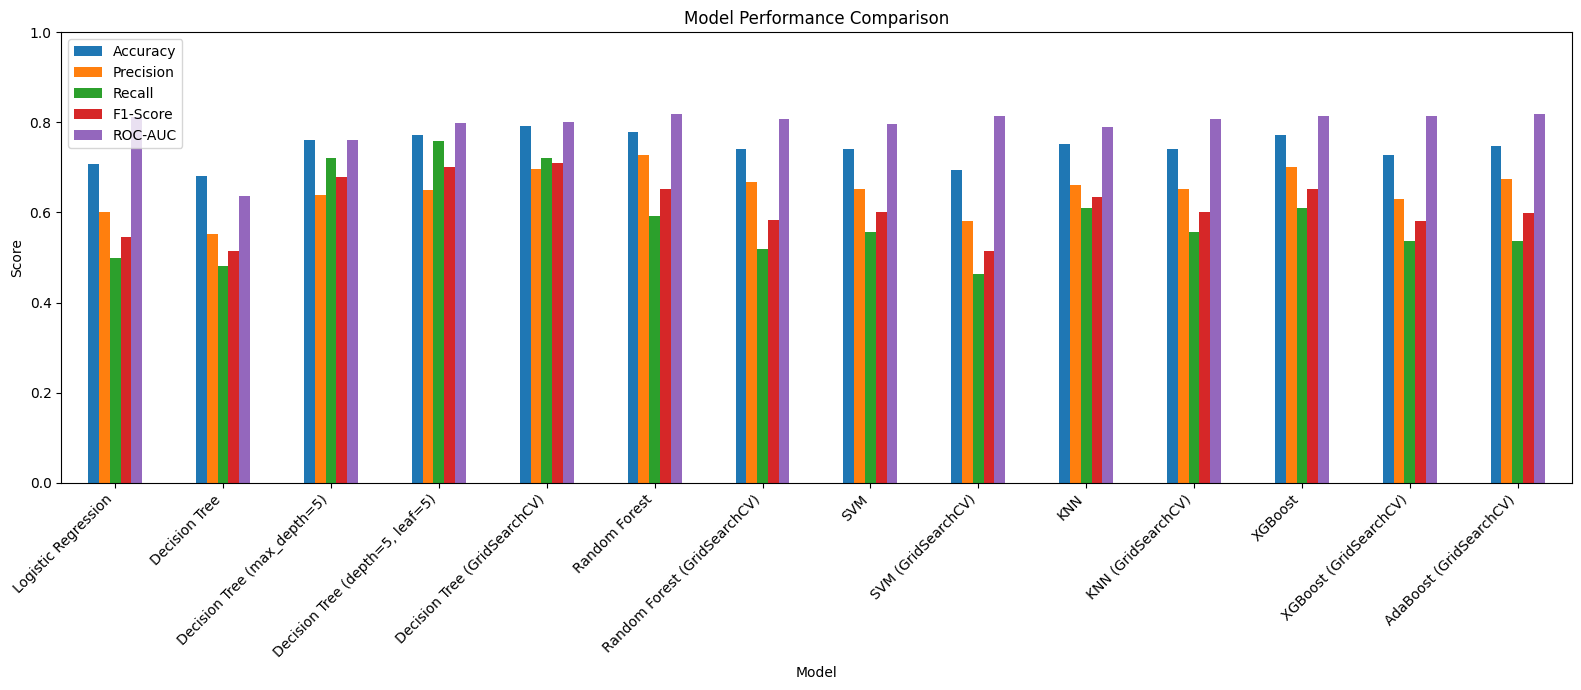

In [ ]:
# Plot model performance comparison

import matplotlib.pyplot as plt

main_comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(16, 7)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# Prepare ROC Curves

In [ ]:
# Import ROC curve function

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Get predicted probabilities for the main models

y_prob_lr = model.predict_proba(X_test_scaled)[:, 1]

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

y_prob_ada = ada_model.predict_proba(X_test)[:, 1]

In [ ]:
# Calculate ROC curve points for each model

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)

fpr_ada, tpr_ada, _ = roc_curve(
    y_test,
    y_prob_ada
)

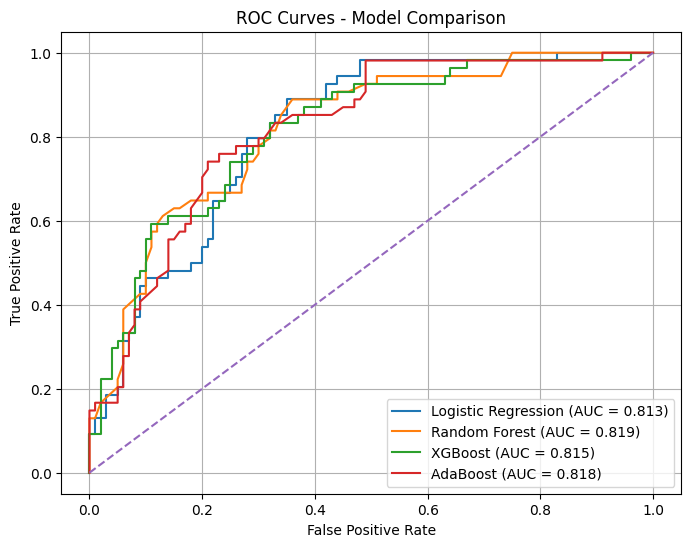

In [ ]:
# Plot ROC curves for the main models

plt.figure(figsize=(8, 6))

# Logistic Regression
plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

# Random Forest
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

# XGBoost
plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {xgb_roc_auc:.3f})"
)

# AdaBoost
plt.plot(
    fpr_ada,
    tpr_ada,
    label=f"AdaBoost (AUC = {ada_roc_auc:.3f})"
)

# No-skill reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")

plt.legend()
plt.grid()
plt.show()

In [ ]:
# Create a ROC-AUC comparison table

roc_auc_comparison = results_df_rounded[
    ["Model", "ROC-AUC"]
].sort_values(
    by="ROC-AUC",
    ascending=False
)

# Display the comparison

roc_auc_comparison

,Model,ROC-AUC
5,Random Forest,0.819
13,AdaBoost (GridSearchCV),0.818
8,SVM (GridSearchCV),0.815
11,XGBoost,0.815
12,XGBoost (GridSearchCV),0.814
0,Logistic Regression,0.813
6,Random Forest (GridSearchCV),0.807
10,KNN (GridSearchCV),0.807
4,Decision Tree (GridSearchCV),0.801
3,"Decision Tree (depth=5, leaf=5)",0.799


In [ ]:
# Select precision and recall for comparison

precision_recall_comparison = results_df_rounded[
    ["Model", "Precision", "Recall"]
]

# Display the comparison

precision_recall_comparison

,Model,Precision,Recall
0,Logistic Regression,0.600,0.500
1,Decision Tree,0.553,0.481
2,Decision Tree (max_depth=5),0.639,0.722
3,"Decision Tree (depth=5, leaf=5)",0.651,0.759
4,Decision Tree (GridSearchCV),0.696,0.722
5,Random Forest,0.727,0.593
6,Random Forest (GridSearchCV),0.667,0.519
7,SVM,0.652,0.556
8,SVM (GridSearchCV),0.581,0.463
9,KNN,0.660,0.611


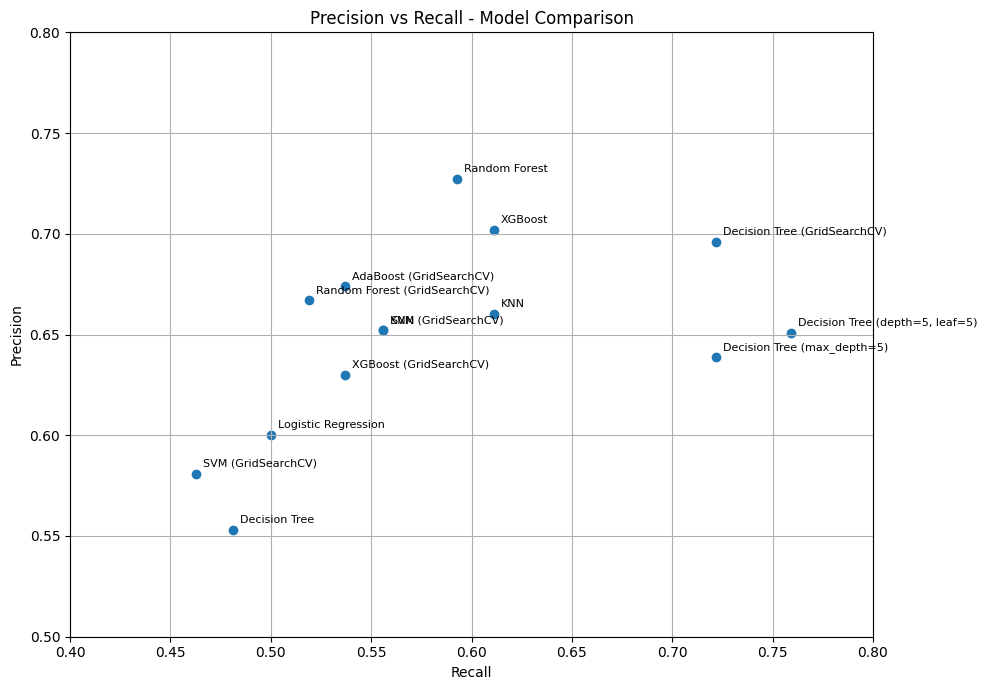

In [ ]:
# Plot precision vs recall for all models

plt.figure(figsize=(10, 7))

plt.scatter(
    precision_recall_comparison["Recall"],
    precision_recall_comparison["Precision"]
)

# Add model names to each point

for _, row in precision_recall_comparison.iterrows():
    plt.annotate(
        row["Model"],
        (row["Recall"], row["Precision"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall - Model Comparison")
plt.xlim(0.4, 0.8)
plt.ylim(0.5, 0.8)
plt.grid()
plt.tight_layout()
plt.show()

# Confusion Matrix Comparison

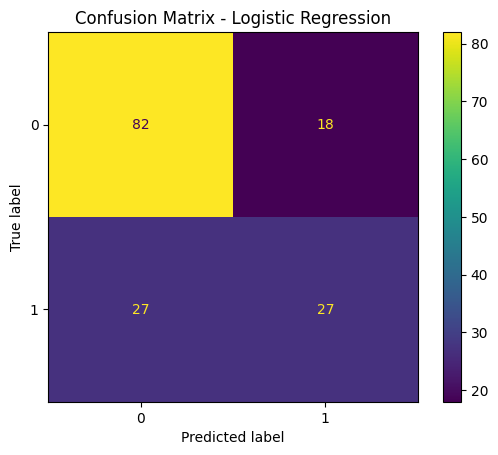

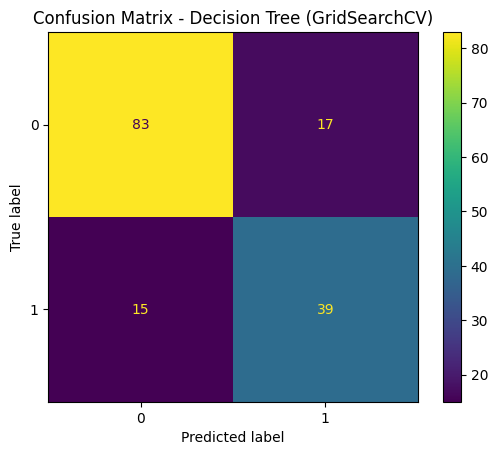

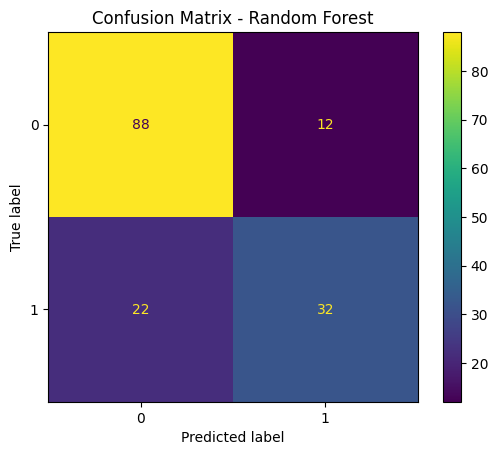

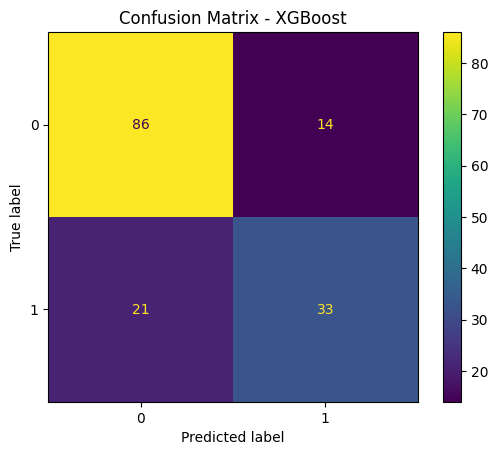

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

models_to_compare = {
    "Logistic Regression": (model, X_test_scaled),
    "Decision Tree (GridSearchCV)": (best_dt, X_test),
    "Random Forest": (rf_model, X_test),
    "XGBoost": (xgb_model, X_test)
}

for model_name, (model_obj, test_data) in models_to_compare.items():

    ConfusionMatrixDisplay.from_estimator(
        model_obj,
        test_data,
        y_test
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

In [ ]:
# Compare confusion matrix values for selected models

from sklearn.metrics import confusion_matrix

confusion_results = []

for model_name, (model_obj, test_data) in models_to_compare.items():

    y_pred = model_obj.predict(test_data)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    confusion_results.append({
        "Model": model_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

confusion_df = pd.DataFrame(confusion_results)

confusion_df

,Model,TN,FP,FN,TP
0,Logistic Regression,82,18,27,27
1,Decision Tree (GridSearchCV),83,17,15,39
2,Random Forest,88,12,22,32
3,XGBoost,86,14,21,33


In [ ]:
# Calculate total errors for each model

confusion_df["Total Errors"] = (
    confusion_df["FP"] + confusion_df["FN"]
)

confusion_df


,Model,TN,FP,FN,TP,Total Errors
0,Logistic Regression,82,18,27,27,45
1,Decision Tree (GridSearchCV),83,17,15,39,32
2,Random Forest,88,12,22,32,34
3,XGBoost,86,14,21,33,35


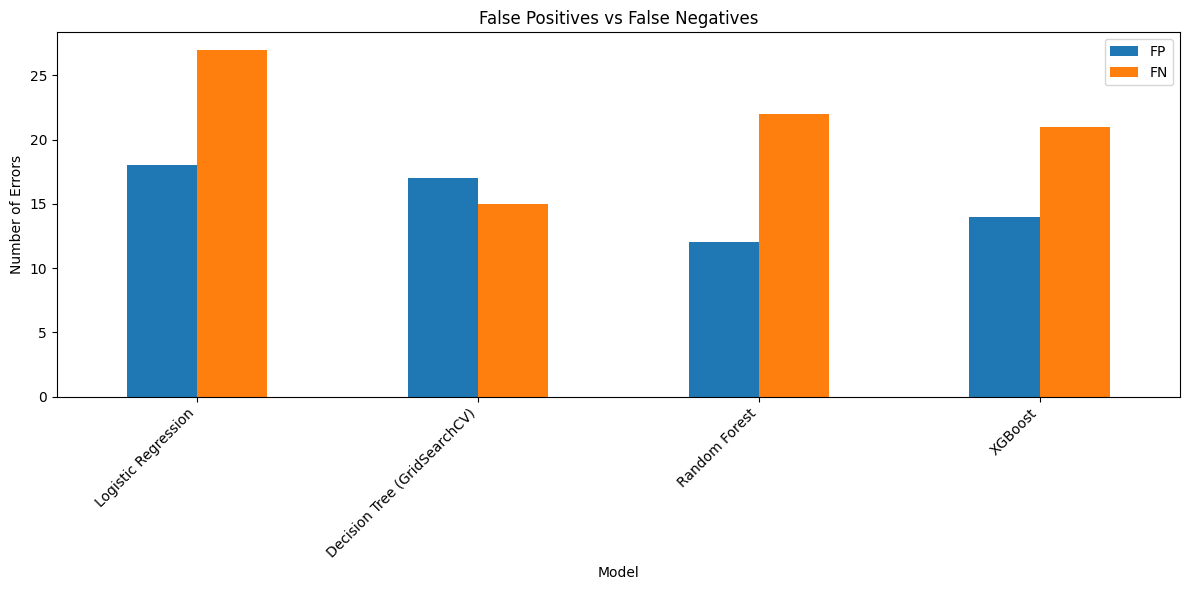

In [ ]:
# Compare false positives and false negatives

error_comparison = confusion_df[
    ["Model", "FP", "FN"]
]

error_comparison.set_index("Model")[
    ["FP", "FN"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("False Positives vs False Negatives")
plt.ylabel("Number of Errors")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Create a final evaluation table for the main models

final_evaluation = results_df_rounded[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
].copy()

final_evaluation

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.708,0.600,0.500,0.545,0.813
1,Decision Tree,0.682,0.553,0.481,0.515,0.636
2,Decision Tree (max_depth=5),0.760,0.639,0.722,0.678,0.762
3,"Decision Tree (depth=5, leaf=5)",0.773,0.651,0.759,0.701,0.799
4,Decision Tree (GridSearchCV),0.792,0.696,0.722,0.709,0.801
5,Random Forest,0.779,0.727,0.593,0.653,0.819
6,Random Forest (GridSearchCV),0.740,0.667,0.519,0.583,0.807
7,SVM,0.740,0.652,0.556,0.600,0.796
8,SVM (GridSearchCV),0.695,0.581,0.463,0.515,0.815
9,KNN,0.753,0.660,0.611,0.635,0.789


In [ ]:
# Find the highest value for each evaluation metric

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

for metric in metrics:
    best_value = final_evaluation[metric].max()

    best_models = final_evaluation[
        final_evaluation[metric] == best_value
    ]["Model"].tolist()

    print(f"{metric}: {best_value:.3f}")
    print("Model:", best_models)
    print()

Accuracy: 0.792
Model: ['Decision Tree (GridSearchCV)']

Precision: 0.727
Model: ['Random Forest']

Recall: 0.759
Model: ['Decision Tree (depth=5, leaf=5)']

F1-Score: 0.709
Model: ['Decision Tree (GridSearchCV)']

ROC-AUC: 0.819
Model: ['Random Forest']



In [ ]:
# Compare training and test accuracy

train_test_results = []

models_for_comparison = {
    "Logistic Regression": (model, X_train_scaled, X_test_scaled),
    "Decision Tree (GridSearchCV)": (best_dt, X_train, X_test),
    "Random Forest": (rf_model, X_train, X_test),
    "XGBoost": (xgb_model, X_train, X_test)
}

for model_name, (model_obj, train_data, test_data) in models_for_comparison.items():

    train_accuracy = model_obj.score(
        train_data,
        y_train
    )

    test_accuracy = model_obj.score(
        test_data,
        y_test
    )

    train_test_results.append({
        "Model": model_name,
        "Training Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Accuracy Gap": train_accuracy - test_accuracy
    })

train_test_df = pd.DataFrame(train_test_results)

train_test_df.round(3)

,Model,Training Accuracy,Test Accuracy,Accuracy Gap
0,Logistic Regression,0.796,0.708,0.089
1,Decision Tree (GridSearchCV),0.785,0.792,-0.007
2,Random Forest,1.000,0.779,0.221
3,XGBoost,1.000,0.773,0.227


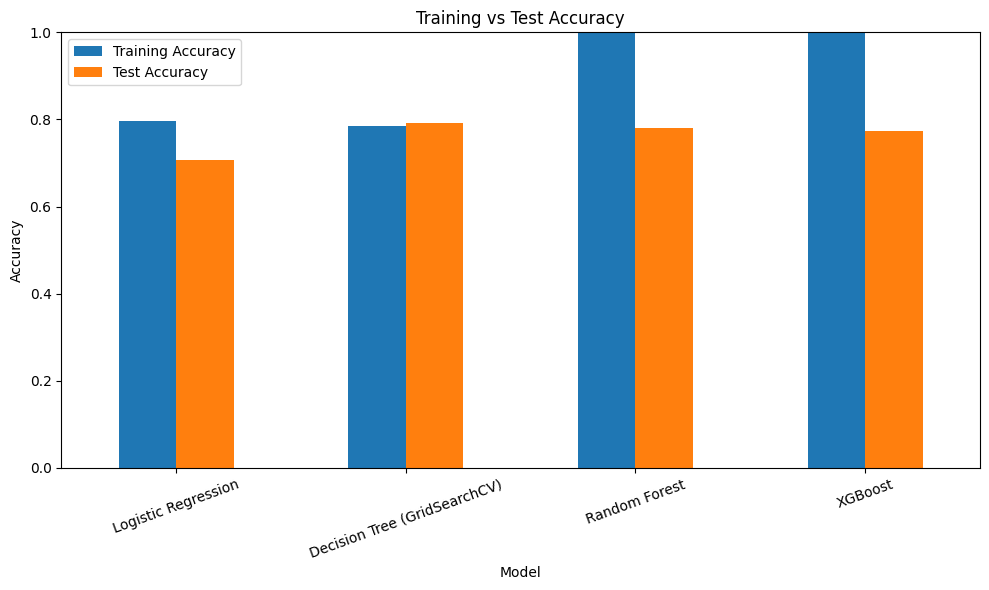

In [ ]:
# Visualize training vs test accuracy

train_test_df.set_index("Model")[
    ["Training Accuracy", "Test Accuracy"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Training vs Test Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Sort models by their training-test accuracy gap

train_test_df.sort_values(
    by="Accuracy Gap",
    ascending=False
).round(3)

,Model,Training Accuracy,Test Accuracy,Accuracy Gap
3,XGBoost,1.000,0.773,0.227
2,Random Forest,1.000,0.779,0.221
0,Logistic Regression,0.796,0.708,0.089
1,Decision Tree (GridSearchCV),0.785,0.792,-0.007


## decision Tree Feature Importance

In [ ]:
## Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_dt.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.round(3)

,Feature,Importance
1,Glucose,0.699
5,BMI,0.149
7,Age,0.137
0,Pregnancies,0.015
3,SkinThickness,0.000
2,BloodPressure,0.000
4,Insulin,0.000
6,DiabetesPedigreeFunction,0.000


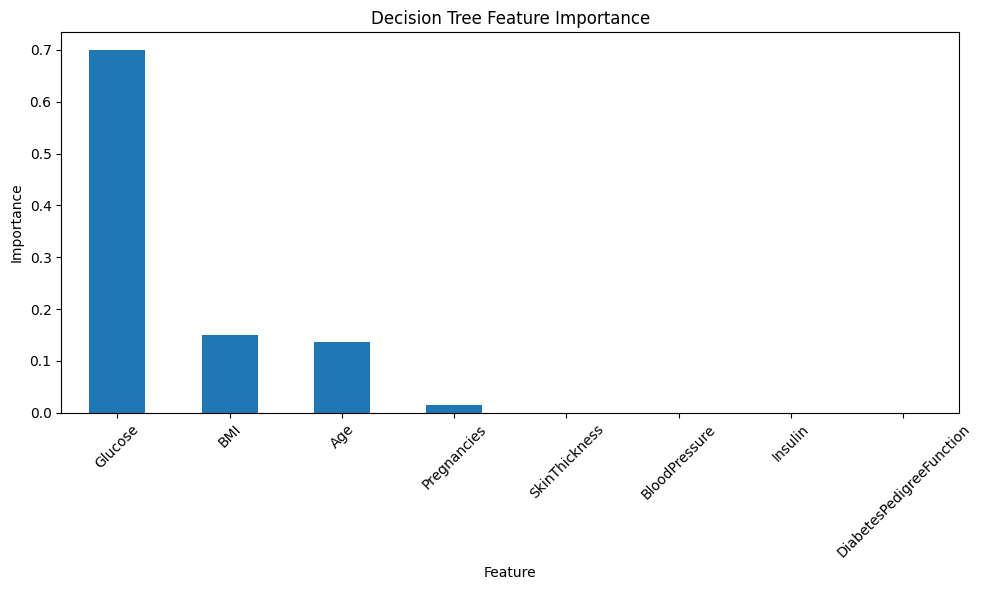

In [ ]:
## Visualize Feature Importance

feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10, 6),
    legend=False
)

plt.title("Decision Tree Feature Importance")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Random Forest Feature Importance

In [ ]:
## Random Forest Feature Importance

rf_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_feature_importance = rf_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_feature_importance.round(3)

,Feature,Importance
1,Glucose,0.274
5,BMI,0.162
6,DiabetesPedigreeFunction,0.125
7,Age,0.113
4,Insulin,0.091
2,BloodPressure,0.084
0,Pregnancies,0.081
3,SkinThickness,0.070


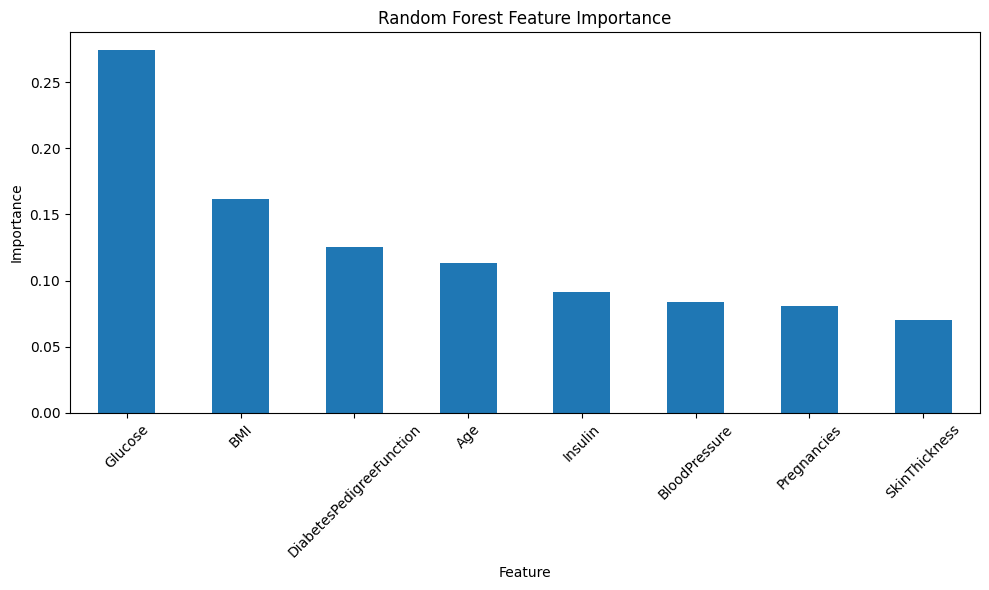

In [ ]:
## Visualize Random Forest Feature Importance

rf_feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10, 6),
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Compare Feature Importance


In [ ]:
## Compare Feature Importance

importance_comparison = pd.merge(
    feature_importance,
    rf_feature_importance,
    on="Feature",
    suffixes=("_DT", "_RF")
)

importance_comparison = importance_comparison.sort_values(
    by="Importance_DT",
    ascending=False
)

importance_comparison.round(3)

,Feature,Importance_DT,Importance_RF
0,Glucose,0.699,0.274
1,BMI,0.149,0.162
2,Age,0.137,0.113
3,Pregnancies,0.015,0.081
4,SkinThickness,0.000,0.070
5,BloodPressure,0.000,0.084
6,Insulin,0.000,0.091
7,DiabetesPedigreeFunction,0.000,0.125


## Compare Decision Tree and Random Forest Feature Importance

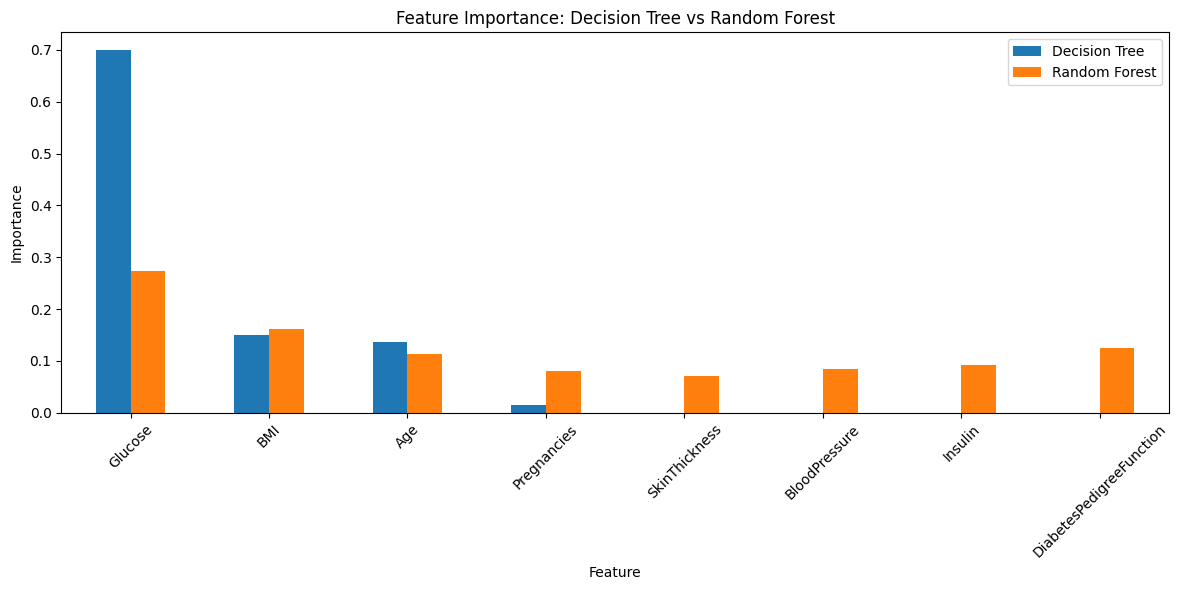

In [ ]:
## Compare Decision Tree and Random Forest Feature Importance

importance_comparison.set_index("Feature")[
    ["Importance_DT", "Importance_RF"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Feature Importance: Decision Tree vs Random Forest")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.legend(["Decision Tree", "Random Forest"])
plt.tight_layout()
plt.show()

## Look at one XGBoost prediction

In [ ]:
## Look at one XGBoost prediction

sample_index = 0

sample = X_test.iloc[[sample_index]]
actual_value = y_test.iloc[sample_index]
predicted_value = xgb_model.predict(sample)[0]
prediction_probability = xgb_model.predict_proba(sample)[0]

print("Actual value:", actual_value)
print("Predicted value:", predicted_value)
print("Probability of class 0:", prediction_probability[0])
print("Probability of class 1:", prediction_probability[1])

Actual value: 0
Predicted value: 1
Probability of class 0: 0.058633506
Probability of class 1: 0.9413665


In [ ]:
## Import SHAP

import shap

## Create a SHAP Explainer

explainer = shap.TreeExplainer(xgb_model)

In [ ]:
## Calculate SHAP Values

shap_explanation = explainer(sample)

## Inspect SHAP Explanation

shap_explanation

.values =
array([[ 0.5538535 ,  3.0597537 , -0.04468559, -0.17787741,  0.437893  ,
        -0.7495887 , -0.37194416,  0.79987365]], dtype=float32)

.base_values =
array([-0.7312507], dtype=float32)

.data =
array([[  7.   , 159.   ,  64.   ,  29.   , 125.   ,  27.4  ,   0.294,
         40.   ]])

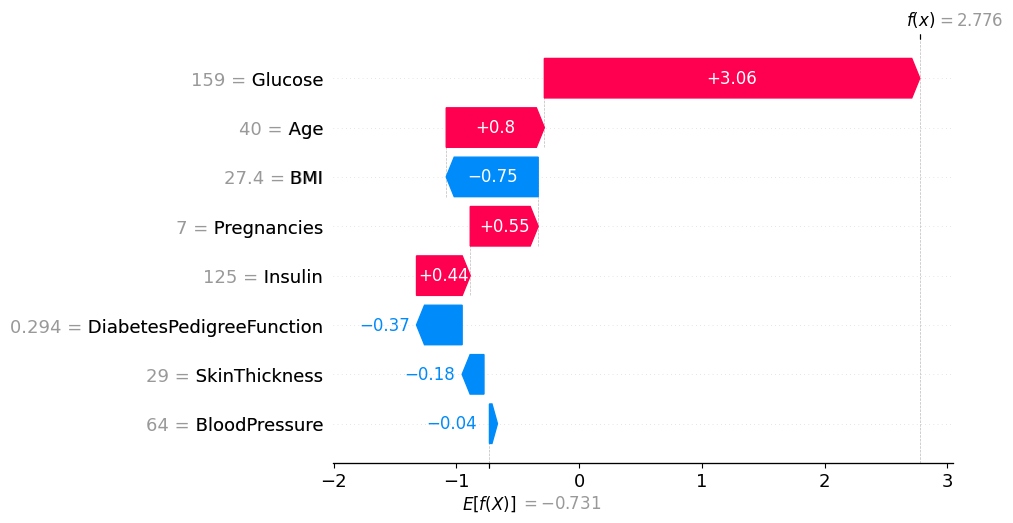

In [ ]:
## SHAP Waterfall Plot

shap.plots.waterfall(shap_explanation[0])


In [ ]:
## SHAP Beeswarm Plot
shap.plots.beeswarm(shap_explanation)

NameError: name 'shap_values' is not defined